# BASE USA




# INTRODUCCION

##OBJETIVO

## FUENTES


El EIA de Estados Unidos realiza la Residential Energy Consumption Survey (RECS) aproximadamente cada 5 años.
Link: ___

Debido a que los datos de 2024 no poseen información del consumo eléctrico aún y los datos del 2020 están atravezados por la Pandemia del COVID-19 afectando los habitos de consumo, se decide utilizar los datos del 2015.

El diseño muestral es un diseño multietápico, donde el país de divide en regiones y subregiones cada vez más pequeñas, hasta que finalmente llegar a los hogares. La base de datos provée de los pesos de cada observación.

La muestra inicial constó de  12,753 hogares, aunque solo 5,686 completaron la encuesta (tasa de respuesta del 50.8%), si bien esto representa un problema, estos valores son comunes en las estadísticas oficiales.

El consumo de los hogares durante el año de referencia (2015) es provisto por la Energy Supplier Survey (ESS).

La información sobre el clima es recolectada del National Climate Data Center (NCDC) utilizando las estaciones más cercanas a cada hogar entrevistado.

## SOBRE LA MUESTRA DE VIVIENDAS

El Energy Information Administration (EIA) de Estados Unidos realiza la Residential Energy Consumption Survey (RECS) aproximadamente cada 5 años.
Link: ___

Debido a que los datos de 2024 no poseen información del consumo eléctrico aún y los datos del 2020 están atravezados por la Pandemia del COVID-19 afectando los habitos de consumo, se decidió utilizar los datos del 2015.

El diseño muestral es un diseño multietápico, donde el país de divide en regiones de aproximadamente 10.000 viviendas, estas regiones son muestreadas al azar. Las regiones seleccionadas son subdivididas en subregiones, de cada una de estas subregiones se seleccionan las viviendas.

Para contrarestar el desbalance creado por este diseño, donde no todas las viviendas tienen la misma probabilidad de ser seleccionada la base de datos provée de los pesos de cada observación.

La muestra inicial constó de  12,753 hogares, aunque solo 5,686 completaron la encuesta (tasa de respuesta del 50.8%), si bien esto representa un problema, estos valores son comunes en las estadísticas oficiales.

El consumo de los hogares durante el año de referencia (2015) es provisto por la Energy Supplier Survey (ESS).

La información sobre el clima es recolectada del National Climate Data Center (NCDC) utilizando las estaciones más cercanas a cada hogar entrevistado.

## PIPELINE

| Etapa | Paso | Acciones |
|---|---|---|
| Preparación de la Base     |  Limpieza de la base | Carga de la base con 800 variables y 5600 observaciones.               |
|      | | Eliminación de 540 variables por no contener información relevante para la estimación.     |  
|     | Recodificación      | 180 variables renombradas     |
|     | Validadción  y correciones      | Chequeo de datos faltantes, incongruentes, constantes, esparcidos o altamente correlacionados.|
|  |   | Eliminación de __ variables y reagrupamiento de __.  |
| Análisis Exploratorio |  Análisis gráfico de la variable respuesta |Se decide aplicar la transformación logarimto y eliminar 10 outliers. |
| |  Análisis de Importancia y Correlación | Se chequea no haya variables altamente correlacionadas y se identifican las 15 variables más importantes. |
| |  Análisis de Predictores | Se realizan gráficos sobre cada una de las variables en busqueda de su correcta forma funcional. Se descubre que las variables numéricas se benefician de la transformación logaritmo.|
| Selección de modelos|Selección de modelos |Se aplica validación cruzada para estimar varias metricas de diferentes algorimos. |
| | | Se decide utilizar Regresión Lineal por estar entre los de mayor performance y a la vez es el más sencillo |
| Selección de variables|  Lasso por validación cruzada | Se identifica un alpha que balancee poder predictivo y cantidad de parámetros |
| | Selección por estabilidad | Se aplica muestreo bootstrap para Lasso con el hiperametro seleccionado. Las variables seleccionadas en más de un 80% de los casos pasan al siguinete paso.|
| | Interacción y efectos cuadráticos | Se añaden interacciones y efectos cuadráticos al modelo|
| | Lasso | Se aplica Lasso con diferentes alfa con validación cruzada. |
| Diagnóstico | Análisis de Residuos| Análisis gráfico y de distintas métricas |
| Otros modelos | Regresión Lineal |Utilizando las mismas variables que en los casos anteriores combinados con reglas manuales se estiman cada una de las categorias de consumo |
| Resultados | Modelos | Varios diccionarios con los distintos modelos estimados   |
|  | Error de modelo | Error estandar del los residuos.  |
|   | Percentiles          | Diccionario con los percentiles de consumo. |



## IMPORTS

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm


from scipy.stats import chi2_contingency
from numpy._core.numeric import astype
from warnings import simplefilter

from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    median_absolute_error,
    mean_squared_error,
)



simplefilter(action="ignore", category=pd.errors.PerformanceWarning) # evita que una advertencia ocurra constantemente

## FUNCIONES

###validity_check

In [2]:
def validity_check(data,
                   sparse_threshold=0.99,
                   dominant_threshold=0.70,
                   contiguous_threshold=0.90,
                   corr_threshold=0.70):

    nan_vars = []
    constant_vars = []
    sparse_vars = []
    dominant_vars = []
    contiguous_vars = []
    negative_vars = []

    # ======================================================
    # Variable-by-variable checks
    # ======================================================

    for col in data.columns:

        s = data[col]

        # NaN
        if s.isna().any():
            nan_vars.append(col)

        # Negative values
        if pd.api.types.is_numeric_dtype(s):
            if (s < 0).any():
                negative_vars.append(col)

        # Constant
        if s.nunique(dropna=True) == 1:
            constant_vars.append(col)

        # Sparse (>99% same value)
        freq = s.value_counts(normalize=True, dropna=False)

        if len(freq) > 0:

            if freq.iloc[0] >= sparse_threshold:
                sparse_vars.append(col)

            # Only for variables with >=3 values
            if s.nunique(dropna=True) >= 3:

                # 70% same value
                if freq.iloc[0] >= dominant_threshold:
                    dominant_vars.append(col)

                # 90% in two contiguous values
                vals = s.dropna()

                if pd.api.types.is_numeric_dtype(vals):

                    uniques = np.sort(vals.unique())

                    for i in range(len(uniques)-1):

                        if uniques[i+1] - uniques[i] == 1:

                            prop = (
                                vals.isin([uniques[i], uniques[i+1]])
                                .mean()
                            )

                            if prop >= contiguous_threshold:
                                contiguous_vars.append(col)
                                break

    # ======================================================
    # Correlations
    # ======================================================

    numeric = data.select_dtypes(include=np.number)

    corr = numeric.corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={
            "level_0":"Variable 1",
            "level_1":"Variable 2",
            0:"Correlación"
        })
    )

    high_corr = (
        pairs[pairs["Correlación"] >= corr_threshold]
        .sort_values("Correlación", ascending=False)
    )

    corr_vars = set(high_corr["Variable 1"]).union(high_corr["Variable 2"])

    # ======================================================
    # Report
    # ======================================================
    print("="*70)

    print(f"{data.shape[1]} variables en el dataset.")

    print("="*70)

    print(f"{data.shape[0]} observaciones en el dataset.")


    print("="*70)

    print(f"{len(nan_vars)} variables contienen NA.")
    print(nan_vars)

    print()

    print(f"{len(negative_vars)} variables contienen valores negativos.")
    print(negative_vars)

    print()

    print(f"{len(constant_vars)} variables son constantes.")
    print(constant_vars)

    print()

    print(f"{len(sparse_vars)} variables tienen más del {100*sparse_threshold//1}% del mismo valor.")
    print(sparse_vars)

    print()

    print(f"{len(dominant_vars)} variables tienen más del {100*dominant_threshold//1}% del mismo valor.")
    print(dominant_vars)

    print()

    print(f"{len(contiguous_vars)} variables tienen más del {100*contiguous_threshold//1}% concentrado en dos valores consecutivos.")
    print(contiguous_vars)

    print()

    print(f"{len(corr_vars)} variables tienen al menos una correlación superior a {corr_threshold:.2f}.")

    print("\nTop 10 pares más correlacionados:\n")

    print(high_corr.head(10))

    print("="*70)

    return {
        "NA": nan_vars,
        "Negativos": negative_vars,
        "Constantes": constant_vars,
        "Dispersas": sparse_vars,
        "Dominantes": dominant_vars,
        "Contiguas": contiguous_vars,
        "Correlaciones": high_corr
    }

### weighted_histogram

In [3]:

def weighted_histogram(data, response="KWH", weight=None, bins=40, log=False):
    """
    Crea un histograma de la variable respuesta ponderado por los pesos.

    INPUT:
        data : pandas.DataFrame
            DataFrame que contiene la variable respuesta.

        response : str
            Nombre de la variable respuesta.

        bins : int
            Cantidad de intervalos del histograma.

    OUTPUT:
        Muestra un histograma de la variable respuesta.
    """

    plt.figure(figsize=(8, 5))

    # Select the response variable
    x = data[response].dropna()

    # Initialize weights for the histogram
    hist_weights = None

    if weight:
        # Ensure 'weight' column exists and is numeric
        if weight not in data.columns:
            raise ValueError(f"Weight column '{weight}' not found in data.")

        # Align response and weight data by dropping NaNs from both simultaneously
        temp_df = data[[response, weight]].dropna()
        x = temp_df[response]
        hist_weights = temp_df[weight].astype(float) # Weights should be float

    if log:
        x = np.log10(x)
        xlabel = f"log10( {response} )"
        title = f"Histograma de log {response} "
    else:
        xlabel = response
        title = f"Histograma de {response}"

    plt.ylabel("Frecuencia")

    # Use the 'weights' parameter for a statistically correct weighted histogram
    plt.hist(
        x,
        bins=bins,
        edgecolor="black",
        weights=hist_weights # Pass the weights here
    )
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### random_forest_importance

In [4]:

def random_forest_importance(
    data,
    response="KWH",
    weight="NWEIGHT",
    min_node_size=35,
    max_depth=7,
    n_trees=500,
    top_n=10,
    random_state=123,
    permutation=False,
):
    """
    Ajusta un modelo Random Forest para una variable respuesta continua
    y muestra un gráfico con las variables más importantes.

    Parámetros del modelo:
        - Peso de observaciones.
        - min_node_size = 35
        - max_depth = 7

    INPUT:
        data : pandas.DataFrame
            DataFrame que contiene las variables predictoras, la variable
            respuesta y la variable de ponderación.

        response : str
            Nombre de la variable respuesta.

        weight : str
            Nombre de la variable de ponderación.

        min_node_size : int
            Cantidad mínima de observaciones por nodo terminal.

        max_depth : int
            Profundidad máxima del árbol.

        n_trees : int
            Número de árboles.

        top_n : int
            Cantidad de variables a mostrar.

        permutation : bool
            Si True utiliza Permutation Importance.
            Si False utiliza la importancia por reducción de impureza.

    OUTPUT:
        importance : pandas.DataFrame
            Tabla ordenada de importancia de variables.

        model : RandomForestRegressor
            Modelo ajustado.

        Además muestra un gráfico de barras con las variables más importantes.
    """

    # -------------------------
    # Preparar datos
    # -------------------------
    X = data.drop(columns=[response, weight]).select_dtypes(include="number")
    y = data[response]
    w = data[weight]

    # -------------------------
    # Ajustar modelo
    # -------------------------
    model = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=max_depth,
        min_samples_leaf=min_node_size,
        random_state=random_state,
        n_jobs=-1,
    )

    model.fit(X, y, sample_weight=w)

    # -------------------------
    # Importancia
    # -------------------------
    if permutation:

        perm = permutation_importance(
            model,
            X,
            y,
            sample_weight=w,
            n_repeats=10,
            random_state=random_state,
            n_jobs=-1,
        )

        importance = pd.DataFrame({
            "Variable": X.columns,
            "Importance": perm.importances_mean
        })

    else:

        importance = pd.DataFrame({
            "Variable": X.columns,
            "Importance": model.feature_importances_
        })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )


    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred, sample_weight=w)
    mad = median_absolute_error(y, y_pred, sample_weight=w)
    rmse = mean_squared_error(y, y_pred, sample_weight=w) ** 0.5

    print(f"R²   : {r2:.3f}")
    print(f"MAD  : {mad:.2f}")
    print(f"RMSE : {rmse:.2f}")

    # -------------------------
    # Gráfico
    # -------------------------
    top = (
        importance
        .head(top_n)
        .sort_values("Importance")
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        top["Variable"],
        top["Importance"]
    )

    plt.xlabel("Importancia")
    plt.ylabel("")
    plt.title(f"Top {top_n} variables más importantes")

    plt.tight_layout()
    plt.show()



    return importance

### combo_plot

In [5]:

def weighted_median(values, weights):
    """Weighted median."""
    values = np.asarray(values)
    weights = np.asarray(weights)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cum_weights = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[cum_weights >= cutoff][0]


def combo_plot(data, response, x, weight=None, type="auto", bins=30, log=False):

    """
    Crea un histograma (o gráfico de barras) de la variable x,
    además le superpone un gráfico loess (o de línea de la mediana) de
    la respuesta.
    Si se utilizan los pesos (weights) estos se aplican a ambas variables.

    INPUT
    -----
    data : pandas DataFrame
    response : variable respuesta
    x : variable explicativa (para el histograma)
    weight : peso de las observaciones (opcional)
    type : "auto" para elegir automáticamente, "continuous" para histograma+loess, "discrete" para barras+línea.
    bins : número de columnas en el histograma.

    OUTPUT
    ------
    Muestra los gráficos
    """

    df = data[[response, x]].copy()
    df = df.dropna()

    if log:
        df[response] = np.log10(df[response])

    if weight is None:
        df["_weight"] = 1.0
    else:
        df["_weight"] = data[weight]

    df = df.dropna()

    if type == "auto":
        if df[x].nunique() > 50:
            type = "continuous"
        else:
            type = "discrete"

    fig, ax1 = plt.subplots(figsize=(10,5))

    ############################################################
    # CONTINUOUS
    ############################################################

    if type == "continuous":

        # histogram
        counts, edges = np.histogram(
            df[x],
            bins=bins,
            weights=df["_weight"]
        )

        centers = (edges[:-1] + edges[1:]) / 2
        widths = np.diff(edges)

        ax1.bar(
            centers,
            counts,
            width=widths,
            color="lightgray",
            edgecolor="black",
            alpha=.6
        )

        ax1.set_ylabel("Weighted Frequency")

        # weighted median per bin
        medians = []

        for i in range(len(edges)-1):

            if i == len(edges)-2:
                mask = (df[x] >= edges[i]) & (df[x] <= edges[i+1])
            else:
                mask = (df[x] >= edges[i]) & (df[x] < edges[i+1])

            if mask.sum() == 0:
                medians.append(np.nan)
            else:
                medians.append(
                    weighted_median(
                        df.loc[mask, response],
                        df.loc[mask, "_weight"]
                    )
                )

        ax2 = ax1.twinx()

        centers = np.array(centers)
        medians = np.array(medians)


        ax2.plot(
            centers[~np.isnan(medians)],
            medians[~np.isnan(medians)],
            color="red",
            linewidth=2,
        )

        ax2.set_ylabel(f"Median {response}")

    ############################################################
    # DISCRETE
    ############################################################

    elif type == "discrete":

        summary = []

        for level, group in df.groupby(x):

            summary.append({
                x: level,
                "count": group["_weight"].sum(),
                "median": weighted_median(
                    group[response],
                    group["_weight"]
                )
            })

        summary = pd.DataFrame(summary)
        summary = summary.sort_values(x)

        # Use the actual numerical values for positioning the bars and median line
        x_values_for_plot = summary[x].values

        ax1.bar(
            x_values_for_plot, # Use actual numerical values for positions
            summary["count"],
            color="lightgray",
            edgecolor="black",
            alpha=.6
        )

        ax1.set_ylabel("Weighted Frequency")
        # Set ticks to the actual discrete values and labels to their string representation
        ax1.set_xticks(x_values_for_plot)
        ax1.set_xticklabels(summary[x].astype(str), rotation=45, ha="right")


        ax2 = ax1.twinx()

        ax2.plot(
            x_values_for_plot, # Use actual numerical values for median plot too
            summary["median"],
            color="red",
            marker="o",
            linewidth=2
        )

        ax2.set_ylabel(f"Median {response}")


    if log:
      plt.title(f"Log( {response} ) vs {x}")
    else:
      plt.title(f"{response} vs {x}")
    plt.tight_layout()
    plt.show()

### binary_variable_summary

In [6]:
def weighted_median_binary(values, weights):
    """
    Calcula la mediana ponderada.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)

    mask = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        return np.nan

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cum_weights = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[np.searchsorted(cum_weights, cutoff)]


def binary_variable_summary(
    data,
    variables,
    response,
    weights,
    figsize=(8, 0.45),
    decimals=2
):
    """
    --------------------------------------------------------------------------
    Descripción
    --------------------------------------------------------------------------
    Verifica que todas las variables indicadas sean binarias (0/1) y calcula,
    para cada una, la mediana ponderada de la variable respuesta cuando la
    variable vale 1 y cuando vale 0.

    Luego calcula la diferencia absoluta entre ambas medianas, ordena los
    resultados de mayor a menor diferencia y muestra una tabla como gráfico.

    --------------------------------------------------------------------------
    INPUT
    --------------------------------------------------------------------------
    data : pandas.DataFrame
        Base de datos.

    variables : list
        Lista de variables binarias a analizar.

    response : str
        Variable respuesta numérica.

    weights : str
        Variable de pesos.

    figsize : tuple, default=(8,0.45)
        Tamaño base del gráfico.

    decimals : int, default=2
        Cantidad de decimales a mostrar.

    --------------------------------------------------------------------------
    OUTPUT
    --------------------------------------------------------------------------
    Devuelve un DataFrame con las columnas:

        Variable
        Mediana (1)
        Mediana (0)
        Diferencia

    ordenado por la diferencia absoluta (de mayor a menor).

    Además muestra una tabla como figura.
    --------------------------------------------------------------------------
    """

    #----------------------------------------------------------
    # Verificar variables binarias
    #----------------------------------------------------------

    for var in variables:

        vals = (
            data[var]
            .dropna()
            .unique()
        )

        vals = np.sort(vals)

        if not np.all(np.isin(vals, [0, 1])):
            raise ValueError(
                f"La variable '{var}' no es binaria. Valores encontrados: {vals}"
            )

    #----------------------------------------------------------
    # Calcular estadísticas
    #----------------------------------------------------------

    results = []

    for var in variables:

        d1 = data[data[var] == 1]
        d0 = data[data[var] == 0]

        med1 = weighted_median_binary(
            d1[response],
            d1[weights]
        )

        med0 = weighted_median_binary(
            d0[response],
            d0[weights]
        )

        results.append([
            var,
            med1,
            med0,
            abs(med1 - med0)
        ])

    results = pd.DataFrame(
        results,
        columns=[
            "Variable",
            "Si (log KWH mediano)",
            "No (log KWH mediano)",
            "Diferencia"
        ]
    )

    results = results.sort_values(
        "Diferencia",
        ascending=False,
        ignore_index=True
    )

    #----------------------------------------------------------
    # Mostrar tabla como gráfico
    #----------------------------------------------------------

    nrows = len(results)

    fig, ax = plt.subplots(
        figsize=(10, max(2, figsize[1] * (nrows + 2)))
    )

    ax.axis("off")

    # Prepare table data: round numeric columns and convert all to string
    display_results = results.copy()

    for col in display_results.columns:
        if pd.api.types.is_numeric_dtype(display_results[col]):
            display_results[col] = np.round(display_results[col], decimals)
        display_results[col] = display_results[col].astype(str)


    table = ax.table(
        cellText=display_results.values,
        colLabels=results.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.3)

    # Encabezado en negrita
    for j in range(len(results.columns)):
        table[(0, j)].set_text_props(weight='bold')

    plt.tight_layout()
    plt.show()

    return results

In [7]:
### linear_regression

In [8]:
def linear_regression(
    train_data,
    test_data,
    response,
    weight,
    return_model=False,
):
    """
    Ajusta una regresión lineal ponderada y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame
            Conjunto de entrenamiento.

        test_data : pandas.DataFrame
            Conjunto de prueba.

        response : str
            Variable respuesta.

        weight : str
            Variable de ponderación.

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.

            Si return_model es True, también devuelve el modelo ajustado.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = LinearRegression()

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test
    )

    mad = median_absolute_error(
        y_test,
        pred,
        sample_weight=w_test
    )


    if return_model:
        return model
    else:
        return [r2, mad]


In [9]:
def random_forest(
    train_data,
    test_data,
    response,
    weight,
    max_depth,
    seed=123
):
    """
    Ajusta un Random Forest ponderado y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame

        test_data : pandas.DataFrame

        response : str

        weight : str

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=max_depth,
        min_samples_leaf=35,
        random_state= seed,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test
    )
    mad = median_absolute_error(
        y_test,
        pred,
        sample_weight=w_test
    )

    return [r2, mad]


def random_forest_6(
    train_data,
    test_data,
    response,
    weight,
    seed =123
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=6,
      seed = seed)

def random_forest_8(
    train_data,
    test_data,
    response,
    weight,
    seed = 123
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=8,
      seed = seed)

def random_forest_10(
    train_data,
    test_data,
    response,
    weight,
    seed = 123
):

    return random_forest(
      train_data,
      test_data,
      response,
      weight,
      max_depth=10,
      seed = seed)

In [10]:
def lightgbm(
    train_data,
    test_data,
    response,
    weight,
    learning_rate,
    seed = 123
):
    """
    Ajusta un LightGBM ponderado y evalúa su desempeño
    sobre un conjunto de prueba.

    INPUT:
        train_data : pandas.DataFrame

        test_data : pandas.DataFrame

        response : str

        weight : str

    OUTPUT:
        r2 : float
            R² ponderado sobre el conjunto de prueba.
    """

    # -------------------------
    # Prepare data
    # -------------------------

    X_train = train_data.drop(columns=[response, weight])
    y_train = train_data[response]
    w_train = train_data[weight]

    X_test = test_data.drop(columns=[response, weight])
    y_test = test_data[response]
    w_test = test_data[weight]

    # -------------------------
    # Fit model
    # -------------------------

    model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=learning_rate,
        max_depth=7,
        num_leaves=64,
        min_child_samples=35,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train,
    )

    # -------------------------
    # Predict
    # -------------------------

    pred = model.predict(X_test)

    # -------------------------
    # Evaluate
    # -------------------------

    r2 = r2_score(
        y_test,
        pred,
        sample_weight=w_test,
    )

    mad = median_absolute_error(
        y_test,
        pred,
        sample_weight=w_test,
    )

    return [r2, mad]



def lightgbm_001(
    train_data,
    test_data,
    response,
    weight,
    seed = 123
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.001,
        seed = seed
    )

def lightgbm_01(
    train_data,
    test_data,
    response,
    weight,
    seed = 123
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.01,
        seed = seed
    )


def lightgbm_05(
    train_data,
    test_data,
    response,
    weight,
    seed = 123,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.05,
        seed = seed
    )



def lightgbm_10(
    train_data,
    test_data,
    response,
    weight,
    seed = 123,
):
    return lightgbm(
        train_data=train_data,
        test_data=test_data,
        response=response,
        weight=weight,
        learning_rate=0.10,
        seed = seed
    )

In [11]:
from sklearn.model_selection import KFold

def cross_validation(
    data,
    kfolds,
    list_of_models,
    response,
    weight,
    seed = 123
):
    """
    Performs k-fold cross-validation on one or more prediction models.

    Each model must be a function with the following syntax:

        model(train_data, test_data, response, weight)

    and must return the weighted R² on the test dataset.

    INPUT:
        data : pandas.DataFrame

        kfolds : int

        seed : int

        list_of_models : dict
            Dictionary of the form

                {
                    "Linear": linear_regression,
                    "RF": random_forest,
                    ...
                }

        response : str

        weight : str

    OUTPUT:
        pandas.DataFrame containing the median R² for each model.
    """

    cv = KFold(
        n_splits=kfolds,
        shuffle=True,
        random_state=seed
    )

    results_r2 = {name: [] for name in list_of_models}
    results_mad = {name: [] for name in list_of_models}

    for train_idx, test_idx in cv.split(data):

        train_data = data.iloc[train_idx]
        test_data = data.iloc[test_idx]

        for name, model in list_of_models.items():

            r2_mad = model(
                train_data=train_data,
                test_data=test_data,
                response=response,
                weight=weight,
                seed=seed
            )

            results_r2[name].append(r2_mad[0])
            results_mad[name].append(r2_mad[1])

    summary = pd.DataFrame({
        "Model": list_of_models.keys(),
        "Median_R2": [np.median(v) for v in results_r2.values()],
        "Median_MAD": [np.median(v) for v in results_mad.values()]

    })

    return summary.sort_values(
        "Median_R2",
        ascending=False
    ).reset_index(drop=True)

In [12]:


def lasso_variable_selection(
    data,
    response,
    weight,
    alpha,
    n_bootstraps=20,
    seed=123,
    variable_scores=False,
):
    """
    Performs bootstrap sampling for a Lasso model.

    INPUT
    -----
    data : pandas.DataFrame
    response : str
    weight : str
    alpha : float
        Lasso penalty.
    n_bootstraps : int
        Number of bootstrap simulations.
    seed : int
    variable_scores : bool, default=False
        If True, returns a pandas Series with the number of times each variable
        was selected (non-zero coefficient) across all bootstrap iterations.

    OUTPUT
    ------
    dict with:

        alpha
        median_nonzero
        median_r2
        variable_scores (optional, if variable_scores=True)
    """

    X = (
        data
        .drop(columns=[response, weight])
        .select_dtypes(include=np.number)
    )

    y = data[response].copy()


    w = data[weight]

    r2_values = []
    mad_values = []
    ncoef_values = []
    variable_selection_counts = pd.Series(0, index=X.columns) # Initialize counts for variable_scores

    n_samples = len(data)
    np.random.seed(seed) # Set seed for reproducibility of bootstrap samples
    all_indices = np.arange(n_samples)

    for _ in range(n_bootstraps):
        # Generate bootstrap indices (sampling with replacement)
        train_indices = np.random.choice(all_indices, n_samples, replace=True)

        # Identify out-of-bag indices
        oob_mask = np.ones(n_samples, dtype=bool)
        oob_mask[train_indices] = False
        test_indices = all_indices[oob_mask]

        if len(test_indices) == 0: # Ensure there are OOB samples for evaluation
            continue

        X_train = X.iloc[train_indices]
        X_test = X.iloc[test_indices]

        y_train = y.iloc[train_indices]
        y_test = y.iloc[test_indices]

        w_train = w.iloc[train_indices]
        w_test = w.iloc[test_indices]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = Lasso(
            alpha=alpha,
            random_state=seed,
            max_iter=10000
        )

        model.fit(
            X_train_scaled,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict(X_test_scaled)

        r2_values.append(
            r2_score(
                y_test,
                pred,
                sample_weight=w_test
            )
        )
        mad_values.append(
            median_absolute_error(
                y_test,
                pred,
                sample_weight=w_test
            )
        )

        # Count non-zero coefficients for variable_scores
        selected_coef_indices = np.where(model.coef_ != 0)[0]
        if len(selected_coef_indices) > 0:
            selected_variables_in_iter = X.columns[selected_coef_indices]
            variable_selection_counts[selected_variables_in_iter] += 1

        ncoef_values.append(
            np.sum(model.coef_ != 0)
        )

    result = {
        "alpha": alpha,
        "median_nonzero": int(np.median(ncoef_values)),
        "median_r2": np.median(r2_values),
        "median_mad": np.median(mad_values),

    }

    if variable_scores:
        result["variable_scores"] = variable_selection_counts

    return result

### cross_validation_linear

In [13]:



def cross_validation_linear(
    data,
    predictors,
    response,
    weight,
    kfolds=10,
    seed=123,
    transformation = "linear"
):

    cv = KFold(
        n_splits=kfolds,
        shuffle=True,
        random_state=seed
    )

    r2_list = []
    mae_list = []
    mae80_list = []
    mae90_list = []
    mae95_list = []

    se_list = []

    for train_idx, test_idx in cv.split(data):

        train = data.iloc[train_idx]
        test = data.iloc[test_idx]

        X_train = sm.add_constant(train[predictors], has_constant="add")
        X_test = sm.add_constant(test[predictors], has_constant="add")

        y_train = train[response]
        y_test = test[response]

        w_train = train[weight]
        w_test = test[weight]

        if transformation == "linear":
            pass
        elif transformation == "log":
            y_train = np.log10(y_train)
        elif transformation == "sqrt":
            y_train = np.sqrt(y_train)
        elif transformation == "logit":
            y_train = np.log(y_train / (1 - y_train))

        # ---------- Linear Regression ----------


        model = sm.WLS(
            y_train,
            X_train,
            weights=w_train
        ).fit()

        pred = model.predict(X_test)

        if transformation == "linear":
            pass
        elif transformation == "log":
            pred = 10**(pred)
        elif transformation == "sqrt":
            pred = pred**2
        elif transformation == "logit":
            pred = 1 / (1 + np.exp(-pred))

        # ---------- Weighted R² ----------
        y_bar = np.average(y_test, weights=w_test)

        ss_res = np.sum(w_test * (y_test - pred) ** 2)
        ss_tot = np.sum(w_test * (y_test - y_bar) ** 2)

        r2 = 1 - ss_res / ss_tot

        # ---------- Weighted Median Absolute Error ----------
        abs_error = np.abs(y_test - pred)

        order = np.argsort(abs_error)
        abs_error = abs_error.iloc[order].to_numpy()
        weights = w_test.iloc[order].to_numpy()

        mae = abs_error[np.cumsum(weights) >= weights.sum()*0.5][0]

        if any(np.cumsum(weights) >= weights.sum()*0.80):
           mae_80 = abs_error[np.cumsum(weights) >= weights.sum()*0.80][0]
        else:
           mae_80 = abs_error[-1]

        if any(np.cumsum(weights) >= weights.sum()*0.90):
           mae_90 = abs_error[np.cumsum(weights) >= weights.sum()*0.90][0]
        else:
           mae_90 = abs_error[-1]


        if any(np.cumsum(weights) >= weights.sum()*0.95):
           mae_95 = abs_error[np.cumsum(weights) >= weights.sum()*0.95][0]
        else:
           mae_95 = abs_error[-1]


        # ---------- Weighted Residual Standard Error ----------
        p = X_train.shape[1]        # intercept included
        se = np.sqrt(ss_res / (w_test.sum() - p))

        r2_list.append(r2)
        mae_list.append(mae)
        mae80_list.append(mae_80)
        mae90_list.append(mae_90)
        mae95_list.append(mae_95)


        se_list.append(se)

    return pd.DataFrame({
        "Median_R2": [np.median(r2_list)],
        "Median_MAE": [np.median(mae_list)],
        "80%_MAE": [np.median(mae80_list)],
        "90%_MAE": [np.median(mae90_list)],
        "95%_MAE": [np.median(mae95_list)],

        "Median_SE": [np.median(se_list)]
    })

### residual_plot

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

def residual_plot(data, response, weight = None, log = False):
    # ============================
    # Prepare data
    # ============================


    X = data.drop(columns=[response])
    y = data[response]

    if log:
        y = np.log10(y)

    # Remove weight from predictors if present
    if weight:
        X = X.drop(columns=[weight])
        w = data[weight]
    else:
        w = None


    # Add intercept
    X = sm.add_constant(X)

    # ============================
    # Fit weighted linear regression
    # ============================

    model = sm.WLS(y, X, weights=w)
    results = model.fit()

    print(results.summary())

    # ============================
    # Diagnostics
    # ============================

    fitted = results.fittedvalues
    residuals = results.resid
    abs_residuals = np.abs(residuals)

    # ----------------------------
    # Histogram of residuals
    # ----------------------------

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=40)
    plt.title("Residual Histogram")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    # ----------------------------
    # Residuals vs Fitted
    # ----------------------------

    plt.figure(figsize=(6,4))

    plt.scatter(fitted, residuals, s=8, alpha=0.4)

    # LOESS curve
    loess = lowess(residuals, fitted, frac=0.3)
    plt.plot(loess[:,0], loess[:,1], color="red", linewidth=2)

    plt.axhline(0, color="black", linestyle="--")

    plt.title("Residuals vs Fitted")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    plt.show()

    # ----------------------------
    # Absolute Residuals vs Fitted
    # ----------------------------

    plt.figure(figsize=(6,4))

    plt.scatter(fitted, abs_residuals, s=8, alpha=0.4)

    # LOESS curve
    loess = lowess(abs_residuals, fitted, frac=0.3)
    plt.plot(loess[:,0], loess[:,1], color="red", linewidth=2)

    plt.title("Absolute Residuals vs Fitted")
    plt.xlabel("Fitted values")
    plt.ylabel("|Residual|")
    plt.grid(alpha=0.3)
    plt.show()

### weihted_percentile

In [15]:
def weighted_percentiles(data, value, weight, percentiles):
    """
    Compute weighted percentiles.

    Parameters
    ----------
    data : DataFrame
    value : str
        Variable whose percentiles are desired.
    weight : str
        Survey weight.
    percentiles : iterable
        Percentiles between 0 and 1.

    Returns
    -------
    dict
    """

    df = data[[value, weight]].sort_values(value).reset_index(drop=True)

    cumsum = df[weight].cumsum()
    total = cumsum.iloc[-1]

    out = {}

    for p in percentiles:
        target = p * total
        idx = cumsum.searchsorted(target)
        out[p] = df.iloc[idx][value]

    return out

### get_model

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pprint

def get_model(
    df: pd.DataFrame,
    y_col: str,
    x_cols: list[str],
    weight_col: str,
    normalize_weights: bool = True,
    print_dict: bool = True
) -> dict:
    """
    Fit weighted linear regression and return a reusable model_info dictionary.

    By default the expansion factors are normalized (mean weight = 1)
    so that the residual scale is on the original scale of y.
    """
    y = df[y_col].values
    X = sm.add_constant(df[x_cols], prepend=True)          # column name = "const"
    weights = df[weight_col].values.astype(float)

    if normalize_weights:
        weights = weights / weights.mean()                 # mean(weight) = 1

    model = sm.WLS(y, X, weights=weights).fit()

    # Unweighted RMSE (always on the original scale of y) – useful for reference
    unweighted_rmse = float(np.sqrt(np.mean(model.resid ** 2)))

    model_info = {
        "coefs": model.params.to_dict(),                   # "const", ...
        "cov": model.cov_params().values,                  # full covariance matrix
        "df_resid": int(model.df_resid),
        "scale": float(np.sqrt(model.scale)),              # residual SE (now on y-scale)
        "unweighted_rmse": unweighted_rmse,
        "nobs": int(model.nobs),
        "rsquared": float(model.rsquared),
        "weights_normalized": normalize_weights,
    }

    if print_dict:
        print("model_info = ")
        pprint.pprint(model_info, width=120, sort_dicts=False)
        print()

    return model_info

# ETAPA 1: LIMPIEZA DE LA BASE

## CARGA DEL DATA SET

La base tiene 759 variables, y 5685 obserbaciones.
Se chequea que esos datos estén correctos.

In [16]:
# Carga dataset
##Rama Main:
#url = "https://raw.githubusercontent.com/No-Country-simulation/Team45-G9/refs/heads/main/bases/USA/recs2015_public_v4.csv"
## Rama data_science:
url = "https://raw.githubusercontent.com/No-Country-simulation/Team45-G9/refs/heads/data_science/data_science/bases/EEUU/recs2015_public_v4.csv"

data = pd.read_csv(url)

print(data.head())
print(data.info())

   DOEID  REGIONC  DIVISION METROMICRO UATYP10  TYPEHUQ  ZTYPEHUQ  CELLAR  \
0  10001        4        10      METRO       U        2         0       0   
1  10002        3         7       NONE       R        2         0       0   
2  10003        3         6      METRO       U        2         0       1   
3  10004        2         4      MICRO       C        2         0       1   
4  10005        1         2      METRO       U        2         0       1   

   ZCELLAR  BASEFIN  ...  ZELAMOUNT  NGXBTU  PERIODNG  ZNGAMOUNT  FOXBTU  \
0        0       -2  ...          0  103.32         1          0  137.45   
1        0       -2  ...          1     NaN        -2         -2  137.45   
2        0        1  ...          0  100.14         1          0  137.45   
3        0        1  ...          0     NaN        -2         -2  137.45   
4        0        0  ...          0  102.83         1          0  137.45   

   PERIODFO  ZFOAMOUNT  LPXBTU  PERIODLP  ZLPAMOUNT  
0        -2         -2   9

## RECODIFICACION

Se seleccionan variables, descartando aquellas asociadas al diseño muestral, indicadoras de imputación, estimaciones sobre el consumo de distintos combustibles o su costo, con información redundante o dificiles de conocer para el usuario.

Siempre que sea posible se convierte las variables multicategóricas en dummies. Los valores 'no aplica' son convertidos en ceros ('no tiene/ninguno').
Variables dadas por intervalos son mapeadas a numéricas bajo distintos criterios, en general se utiliza la media del intervalor.

Se logra reducir un dataset de 759 variables a 233.

In [17]:
# Crea un dataset vacío
data_1 = pd.DataFrame(index=data.index)

#Consumo
data_1['KWH'] = data['KWH']
#Pesos
data_1['NWEIGHT'] = data['NWEIGHT']

##urbanización según censo 2010
data_1['ZONA_rural'] = (data["UATYP10"] == 'R').astype(int)
## Division
data_1['DIVISION_new_england'] = (data["DIVISION"] == 1 ).astype(int)
data_1['DIVISION_middle_atlantic'] = (data["DIVISION"] == 2 ).astype(int)
data_1['DIVISION_east_north_central'] = (data["DIVISION"] == 3 ).astype(int)
data_1['DIVISION_west_north_central'] = (data["DIVISION"] == 4 ).astype(int)
data_1['DIVISION_south_atlantic'] = (data["DIVISION"] == 5 ).astype(int)
data_1['DIVISION_east_south_central'] = (data["DIVISION"] == 6 ).astype(int)
data_1['DIVISION_west_south_central'] = (data["DIVISION"] == 7 ).astype(int)
data_1['DIVISION_mountain_north'] = (data["DIVISION"] == 8 ).astype(int)
data_1['DIVISION_mountain_south'] = (data["DIVISION"] == 9 ).astype(int)
# PACIFIC --> referencia por ser la mayoritaria
## Dias grados de calefaccion y enfriamieno


data_1['CLIMA_grados_dias_calefaccion'] = data["HDD65"]
data_1['CLIMA_grados_dias_enfriamiento'] = data["CDD65"]
#

# Vivienda y sus habitaciones
##Tipo
data_1['VIVIENDA_movil'] = (data["TYPEHUQ"] == 1).astype(int)
data_1['VIVIENDA_casa_independiente'] = (data["TYPEHUQ"] == 2).astype(int)
data_1['VIVIENDA_casa_pareada'] = (data["TYPEHUQ"] == 3).astype(int)
data_1['VIVIENDA_departamento_2_4'] = (data["TYPEHUQ"] == 4).astype(int)
data_1['VIVIENDA_departamento_5'] = (data["TYPEHUQ"] == 5).astype(int)
## Pisos
map={10: 1.0, 20:2.0 , 31:3.0 , 32:4.0 , 40:1.5, -2:0 }
data_1['PISOS'] = data['STORIES'].map(map)
## Antiguedad  YEARMADERANGE
map={1: 1945, 2:1955 , 3:1965 , 4:1975 , 5:1985, 6:1995, 7:2005, 8:2015}
data_1['ANTIGUEDAD'] = 2015 - data['YEARMADERANGE'].map(map)
## Ocupación   OCCUPYYRANGE
map={1: 1945, 2:1955 , 3:1965 , 4:1975 , 5:1985, 6:1995, 7:2005, 8:2015}
data_1['OCUPACION'] = 2015 - data['OCCUPYYRANGE'].map(map)
##
data_1['TECHOS_altos'] = (data['HIGHCEIL']== 1).astype(int)
data_1['VENTANA_BALCON'] = (data['DOOR1SUM']== 1).astype(int)
map={10: 1.5, 20:4.0 , 30:7.5 , 41:12.5 , 42:17.5, 50:24.5, 60:34.5}
data_1['VENTANAS'] = data['WINDOWS'].map(map)
data_1['VENTANA_VIDRIO_simple'] = (data["TYPEGLASS"] == 1).astype(int)
data_1['VENTANA_VIDRIO_doble'] = (data["TYPEGLASS"] == 2).astype(int)
data_1['VENTANA_VIDRIO_triple'] = (data["TYPEGLASS"] == 3).astype(int)
## Tamaño

data_1['TAMANO_sqft'] = data['TOTSQFT_EN']


#Materiales
##WALLTYPE
data_1['MATERIAL_PARED_ladrillo'] = (data["WALLTYPE"] == 1).astype(int)
data_1['MATERIAL_PARED_madera'] = (data["WALLTYPE"] == 2).astype(int)
data_1['MATERIAL_PARED_revestimiento'] = (data["WALLTYPE"] == 3).astype(int)
data_1['MATERIAL_PARED_estuco'] = (data["WALLTYPE"] == 4).astype(int)
data_1['MATERIAL_PARED_tejuela'] = (data["WALLTYPE"] == 5).astype(int)
data_1['MATERIAL_PARED_piedra'] = (data["WALLTYPE"] == 6).astype(int)
data_1['MATERIAL_PARED_hormigon'] = (data["WALLTYPE"] == 7).astype(int)
data_1['MATERIAL_PARED_otro'] = (data["WALLTYPE"] == 9).astype(int)
##ROOFTYPE
data_1['MATERIAL_TECHO_ceramica'] = (data["ROOFTYPE"] == 1).astype(int)
data_1['MATERIAL_TECHO_tejuela_madera'] = (data["ROOFTYPE"] == 2).astype(int)
data_1['MATERIAL_TECHO_metal'] = (data["ROOFTYPE"] == 3).astype(int)
data_1['MATERIAL_TECHO_pizarra_sintetica'] = (data["ROOFTYPE"] == 4).astype(int)
data_1['MATERIAL_TECHO_teja_asfaltica'] = (data["ROOFTYPE"] == 5).astype(int)
data_1['MATERIAL_TECHO_teja_hormigon'] = (data["ROOFTYPE"] == 7).astype(int)
data_1['MATERIAL_TECHO_otro'] = (data["ROOFTYPE"] == 9).astype(int)
data_1['MATERIAL_TECHO_no_aplica'] = (data["ROOFTYPE"] == -2).astype(int)
##WINFRAME
data_1['MATERIAL_MARCO_VENTANA_madera'] = (data["WINFRAME"] == 1).astype(int)
data_1['MATERIAL_MARCO_VENTANA_metal'] = (data["WINFRAME"] == 2).astype(int)
data_1['MATERIAL_MARCO_VENTANA_vinilo'] = (data["WINFRAME"] == 3).astype(int)
data_1['MATERIAL_MARCO_VENTANA_compuesto'] = (data["WINFRAME"] == 4).astype(int)
data_1['MATERIAL_MARCO_VENTANA_fibra_de_vidrio'] = (data["WINFRAME"] == 5).astype(int)
# Se descarta aislamiento por ser dificil de definir
#Electricidad
##
data_1['ELECTRICIDAD_calentar'] = (data["ELWARM"] == 1).astype(int)
data_1['ELECTRICIDAD_enfriar'] = (data["ELCOOL"] == 1).astype(int)
data_1['ELECTRICIDAD_calentar_agua'] = (data["ELWATER"] == 1).astype(int)
data_1['ELECTRICIDAD_cocinar'] = (data["ELFOOD"] == 1).astype(int)
#ITEMS
## Piscina, Sauna, Generador, Vehiculo Electrico
data_1['PISCINA'] = (data["SWIMPOOL"] == 1).astype(int)
data_1['PISCINA_meses'] = data["MONPOOL"].clip(lower=0)
data_1['PISCINA_caliente'] = (data["POOL"] == 1).astype(int)
data_1['PISCINA_caliente_electrica'] = (data["FUELPOOL"] == 5).astype(int)
data_1['SAUNA'] = (data["RECBATH"] == 1).astype(int)
data_1['SAUNA_meses'] = data["MONTUB"].clip(lower=0)
data_1['SAUNA_electrico'] = (data["FUELTUB"] == 5).astype(int)
data_1['GENERADOR'] = (data["BACKUP"] == 1).astype(int)
data_1['VEHICULO_ELECTRICO'] = (data["ALTFUELPEV"] == 1).astype(int)
## Electrodomésticos
data_1['REFRIGERADOR'] = data['NUMFRIG']
map={1: 1.0, 2:3.0 , 3:7.0 , 41:12.0 , 42:17.0, 5:25.0, -2:0}
data_1['REFRIGERADOR_antiguedad'] = data['AGERFRI1'].map(map)
# Se descartan tamaño, tipo, ubicación del refrigerador y del segundo refrigerador
data_1['FREEZER'] = data['NUMFREEZ']
map={1: 1.0, 2:3.0 , 3:7.0 , 41:12.0 , 42:17.0, 5:25.0, -2:0}
data_1['FREEZER_antiguedad'] = data['AGERFRI1'].map(map)
# Se descartan tipo, tamaño del freezer y del segundo freezer

data_1['HORNO'] = data['STOVEN']
data_1['HORNO_electrico'] = (data['STOVENFUEL']==5).astype(int)
data_1['HORNO_hornalla_electrica'] = (data['DUALCOOKTFUEL']==5).astype(int)
data_1['HORNO_horno_electrico'] = (data['DUALOVENFUEL']==5).astype(int)
data_1['HORNO_hornalla_frecuencia'] = data['COOKTUSE'].clip(lower=0)
data_1['HORNO_horno_frecuencia'] = data['OVENUSE'].clip(lower=0)
data_1['HORNO_hornalla_otras'] = data['STOVE']
data_1['HORNO_hornalla_otras_electricas'] = (data['STOVEFUEL']==5).astype(int)
data_1['HORNO_hornalla_otras_frecuencia'] = data['SEPCOOKTUSE'].clip(lower=0)
data_1['HORNO_horno_otros'] = data['OVEN']
data_1['HORNO_horno_otros_electricas'] = (data['OVENFUEL']==5).astype(int)
data_1['HORNO_horno_otros_frecuencia'] = data['SEPOVENUSE'].clip(lower=0)

data_1['MICROONDAS'] = data['MICRO']
data_1['MICROONDAS_frecuencia'] = data['AMTMICRO'].clip(lower=0)
data_1['PARRILA'] = data['OUTGRILL']
map={1:21.0, 2: 14.0, 3: 7.0, 4: 3.0, 5:1.0 , 6:0.5, 0:0.0}
data_1['PARRILA_frecuencia'] = data['NUMMEAL'].map(map)
data_1['TOSTADORA'] = data['TOAST']
data_1['HORNO_TOSTADOR'] = data['TOASTOVN']
data_1['CAFETERA'] = data['COFFEE']
data_1['OLLA_PRESION'] = data['CROCKPOT']
data_1['PROCESADORA'] = data['FOODPROC']

data_1['ARROCERA'] = data['RICECOOK']

data_1['LICUADORA'] = data['BLENDER']
data_1['ELECTRODOMESTICOS_PEQUENOS_OTROS'] = data['APPOTHER'].clip(lower=0  )
data_1['LAVAVAJILLAS'] = data['DISHWASH']
data_1['LAVAVAJILLAS_frecuencia'] = data['DWASHUSE'].clip(lower=0  )
data_1['LAVAVAJILLAS_ciclo_normal_sin_secado'] = (data['DWASHUSE']==1).astype(int)
data_1['LAVAVAJILLAS_ciclo_normal_con_secado'] = (data['DWASHUSE']==2).astype(int)
data_1['LAVAVAJILLAS_ciclo_ollas_sartenes'] = (data['DWASHUSE']==3).astype(int)
data_1['LAVAVAJILLAS_ciclo_delicados'] = (data['DWASHUSE']==4).astype(int)
data_1['LAVAVAJILLAS_ciclo_ahorro'] = (data['DWASHUSE']==5).astype(int)
map = {1:1.0 , 2:3.0 , 3:7.0 , 41:12.0 ,42:17.0 , 5:25.0 , -2:0.0}
data_1['LAVAVAJILLAS_antiguedad'] = data['AGECWASH'].map(map)

data_1['LAVARROPAS'] = data['CWASHER']
data_1['LAVARROPAS_arriba'] = (data['TOPFRONT'] == 1).astype(int)
data_1['LAVARROPAS_frontal'] = (data['TOPFRONT'] == 2).astype(int)
data_1['LAVARROPAS_frecuencia'] = data['WASHLOAD'].clip(lower=0)
data_1['LAVARROPAS_temperatura_caliente'] = (data['WASHTEMP']==1).astype(int)
data_1['LAVARROPAS_temperatura_templado'] = (data['WASHTEMP']==2).astype(int)
data_1['LAVARROPAS_temperatura_frio'] = (data['WASHTEMP']==3).astype(int)
data_1['LAVARROPAS_enjuague_caliente'] = (data['RNSETEMP']==1).astype(int)
data_1['LAVARROPAS_enjuague_templado'] = (data['RNSETEMP']==2).astype(int)
data_1['LAVARROPAS_enjuague_frio'] = (data['RNSETEMP']==3).astype(int)
map = {1:1.0 , 2:3.0 , 3:7.0 , 41:12.0 ,42:17.0 , 5:25.0 , -2:0.0}
data_1['LAVARROPAS_antiguedad'] = data['AGECWASH'].map(map)
data_1['SECARROPAS'] = data['DRYER']
data_1['SECARROPAS_electrico'] = (data['DRYRFUEL']==5).astype(int)
data_1['SECARROPAS_frecuencia'] = data['DRYRUSE'].clip(lower=0)
map = {1:1.0 , 2:3.0 , 3:7.0 , 41:12.0 ,42:17.0 , 5:25.0 , -2:0.0}
data_1['SECARROPAS_antiguedad'] = data['AGECDRYER'].map(map)
data_1['TV'] = data['TVCOLOR']
map = { 1:27.0, 2:33.5, 3:49.5, 4:60.0, -2:0.0}
data_1['TV_tamano'] = data['TVSIZE1'].map(map)
data_1['TV_lcd'] = (data['TVTYPE1'] == 1).astype(int)
data_1['TV_plasma'] = (data['TVTYPE1'] == 2).astype(int)
data_1['TV_led'] = (data['TVTYPE1'] == 3).astype(int)
data_1['TV_projector'] = (data['TVTYPE1'] == 4).astype(int)
data_1['TV_tubo'] = (data['TVTYPE1'] == 5).astype(int)
map = {1:2.5 , 2:10.0 , 3:25.0 , 4:42.5 ,5:55.0 ,  -2:0.0}
data_1['TV_frecuencia_semana_laboral'] = data['TVONWD1'].map(map)
map = {1:1.0 , 2:4.0 , 3:10.0 , 4:17.0 ,5:22.0 ,  -2:0.0}
data_1['TV_frecuencia_fin_de_semana'] = data['TVONWE1'].map(map)
#se descartan los datos del segundo televisor

data_1['TV_DECODIFICADOR_sin_dvr'] = data['CABLESAT'].clip(lower=0)
data_1['TV_DECODIFICADOR_con_dvr'] = data['COMBODVR'].clip(lower=0)
data_1['DVD_BLUERAY'] = data['SEPDVR'].clip(lower=0)
data_1['CONSOLA_JUEGOS'] = data['PLAYSTA'].clip(lower=0)
data_1['VCR'] = data['VCR'].clip(lower=0)
data_1['INTERNET_STREAMING'] = data['INTSTREAM'].clip(lower=0)
data_1['HOME_THEATER'] = data['TVAUDIOSYS'].clip(lower=0)
data_1['COMPUTADORA_ESCRITORIO'] = data['DESKTOP'].clip(lower=0)
data_1['LAPTOP'] = data['NUMLAPTOP'].clip(lower=0)
data_1['TABLET'] = data['NUMTABLET'].clip(lower=0)
data_1['IMPRESORAS_Y_OTROS'] = data['ELPERIPH'].clip(lower=0)
data_1['IMPRESORAS_Y_OTROS'] = data['ELPERIPH'].clip(lower=0)
data_1['SMARTPHONES'] = data['NUMSMPHONE'].clip(lower=0)
data_1['CELULARES'] = data['CELLPHONE'].clip(lower=0)
data_1['INTERNET'] = data['INTERNET']
data_1['INTERNET_wifi'] = data['INWIRELESS'].clip(lower=0)
data_1['TERMOSTATO'] = data['THERMAIN'].clip(lower=0)
data_1['TERMOSTATO_progamable'] = data['PROTHERM'].clip(lower=0)

data_1['HUMIFICADOR'] = data['MOISTURE']
data_1['HUMIFICADOR_meses'] = data['USEMOISTURE'].clip(lower=0)
data_1['HUMIFICADOR'] = data['NOTMOIST']
data_1['HUMIFICADOR_meses'] = data['USENOTMOIST'].clip(lower=0)

data_1['AGUA_CALIENTE_electrica'] = (data['FUELH2O']==5).astype(int)
map={1:1.0, 2:3.0, 3:7.0, 41: 12.0, 42: 17.0, 5:25.0, -2:0.0}
data_1['AGUA_CALIENTE_antiguedad'] = data['WHEATAGE'].map(map)
data_1['AGUA_CALIENTE_dentro'] = (data['H2OHEATAPT']==1).astype(int)
map={1:30.0, 2:40.0, 3: 60.0, 4:0.0, -2:0.0}
data_1['AGUA_CALIENTE_tamano'] = data['WHEATSIZ'].map(map)
data_1['AGUA_CALIENTE_sin_tanque'] = (data['WHEATSIZ']==4).astype(int)
data_1['AGUA_CALIENTE_mas_de_uno'] = data['MORETHAN1H2O'].clip(lower=0)
data_1['AGUA_CALIENTE_otro_electrico'] = (data['FUELH2O2']==5).astype(int)

#se eliminan variables sobre el segundo calentador de agua
map={1:10.0 , 2: 30.0, 3:50.0, 4: 70.0, 5:90.0}

data_1['LUCES'] = data['LGTINNUM'].map(map)
data_1['LUCES_4_horas'] = data['LGTIN4']
map={1:1.0 , 2: 0.75, 3:0.50, 4: 0.25, 0:0.0}
data_1['LUCES_incandescentes_porcentaje'] = data['LGTINCAN'].map(map)
data_1['LUCES_cfl_porcentaje'] = data['LGTINCFL'].map(map)
data_1['LUCES_led_porcentaje'] = data['LGTINLED'].map(map)
data_1['LUCES_timer'] = data['LGTINCNTL']
map={ 0: 0.0, 1:2.5, 2: 7.0, 3: 12.5, -2:0.0}
data_1['LUCES_afuera'] = data['LGTOUTNUM'].map(map)
data_1['LUCES_afuera_detector'] = data['LGTOUTCNTL'].clip(lower=0)
data_1['TERMOSTATO_INTELIGENTE'] = data['SMARTTHERM'].clip(lower=0)

data_1['SMARTMETER'] = data['SMARTMETER'].clip(lower=0)
data_1['SMARTMETER_intervalo'] = data['INTDATA'].clip(lower=0)
data_1['SMARTMETER_intervalo_visto'] = data['INTDATAACC'].clip(lower=0)

## Habitaciones
data_1['SOTANO'] = (data['CELLAR']==1).astype(int)
data_1['SOTANO_terminado'] = (data['BASEFIN']==1).astype(int)
data_1['ATICO'] = (data['ATTIC']==1).astype(int)
data_1['ATICO_terminado'] = (data['ATTICFIN']==1).astype(int)

data_1['GARAGE_adosado'] = (data['PRKGPLC1']==1).astype(int)
map = {1:1, 2:2, 3:3, -2:0}
data_1['GARAGE_tamano'] = data['SIZEOFGARAGE'].map(map)
data_1['MONOAMBIENTE'] = (data['STUDIO']==1).astype(int)
data_1['DORMITORIOS'] = data['BEDROOMS']
data_1['BANOS'] = data['NCOMBATH'] +  data['NHAFBATH']
data_1['BANOS_completos'] = data['NCOMBATH']
data_1['BANOS_servicio'] = data['NHAFBATH']
data_1['HABITACIONES_otras'] = data['OTHROOMS']
data_1['HABITACIONES'] = data['TOTROOMS']

# AIRE ACONDICIONADO
data_1['AIRE_ACONDICIONADO'] = (data['AIRCOND']==1).astype(int)
data_1['AIRE_ACONDICIONADO_TIPO_central'] = (data['COOLTYPE'].isin([1,3])).astype(int)
data_1['AIRE_ACONDICIONADO_TIPO_individual'] = (data['COOLTYPE'].isin([2,3])).astype(int)
data_1['AIRE_ACONDICIONADO_frio_calor'] = (data['CENACHP']==1).astype(int)
map={1:1.0 , 2:3.0 , 3:7.0 , 41:12.0 ,42:17.0 , 5:25.0 , -2:0.0}
data_1['AIRE_ACONDICIONADO_antiguedad'] = data['AGECENAC'].map(map)
data_1['AIRE_ACONDICIONADO_central_termostato'] = (data['THERMAINAC'] == 1).astype(int)
data_1['AIRE_ACONDICIONADO_central_termostato_progamable'] = (data['PROTHERMAC'] == 1).astype(int)

# CALEFACCION
data_1['CALEFACCION'] = (data['HEATHOME'] == 1).astype(int)
data_1['CALEFACCION_equipo'] = ((data['HEATHOME']==1)|(data['DNTHEAT']==1)).astype(int)
data_1['CALEFACCION_TIPO_caldera'] = (data['EQUIPM'] == 2).astype(int)
data_1['CALEFACCION_TIPO_horno_central'] = (data['EQUIPM'] == 3).astype(int)
data_1['CALEFACCION_TIPO_bomba_calor'] = (data['EQUIPM'] == 4).astype(int)
data_1['CALEFACCION_TIPO_electrica_empotrada'] = (data['EQUIPM'] == 5).astype(int)
data_1['CALEFACCION_TIPO_calefactor_empotrado'] = (data['EQUIPM'] == 6).astype(int)
data_1['CALEFACCION_TIPO_calefactor_gas_petroleo'] = (data['EQUIPM'] == 7).astype(int)
data_1['CALEFACCION_TIPO_estufa_lenia'] = (data['EQUIPM'] == 8).astype(int)
data_1['CALEFACCION_TIPO_hogar'] = (data['EQUIPM'] == 9).astype(int)
data_1['CALEFACCION_TIPO_calefactor_electrico_portatil'] = (data['EQUIPM'] == 10).astype(int)
data_1['CALEFACCION_TIPO_otro'] = (data['EQUIPM'] == 21).astype(int)

data_1['CALEFACCION_electrico'] = (data['FUELHEAT'] == 5).astype(int)
map={1:1.0 , 2:3.0 , 3:7.0 , 41:12.0 ,42:17.0 , 5:25.0 , -2:0.0}
data_1['CALEFACCION_antiguedad'] = data['EQUIPAGE'].map(map)
data_1['CALEFACCION_temperatura_invierno_casa'] = data['TEMPHOME'].clip(lower=0)
data_1['CALEFACCION_temperatura_invierno_fuera'] = data['TEMPGONE'].clip(lower=0)
data_1['CALEFACCION_temperatura_invierno_noch'] = data['TEMPNITE'].clip(lower=0)
data_1['CALEFACCION_mas_de_uno'] = (data['EQUIPAUX']==1).astype(int)
data_1['CALEFACCION_otro_electrico'] = (data['FUELAUX']==5).astype(int)
#se descartan las variables sobre el tipo del segundo calefactor
data_1['CALEFACCION_sotano'] = (data['BASEHEAT'] == 1).astype(int)
data_1['CALEFACCION_atico']  = (data['ATTCHEAT'] == 1).astype(int)
data_1['CALEFACCION_garage'] = (data['GARGHEAT'] == 1).astype(int)
data_1['CALEFACCION_ambientes'] = data_1['CALEFACCION'] +  data_1['CALEFACCION_sotano']+data_1['CALEFACCION_atico'] +data_1['CALEFACCION_garage']
# Integrantes del hogar

data_1['HABITANTES'] = data['NHSLDMEM']
data_1['HABITANTES_mayores'] = data['NUMADULT']
data_1['HABITANTES_menores'] = data['NUMCHILD']
data_1['HABITANTES_dias_en_casa'] = 2 + data['ATHOME']
map = {1:15_000.0 , 2: 30_000.0, 3:50_000.0 , 4: 70_000.0, 5:90_000.0 , 6:110_000.0, 7:130_000.0, 8:150_000.0}
data_1['INGRESO_total'] = data['MONEYPY'].map(map)
data_1['INGRESO_per_capita'] = data_1['INGRESO_total'] / data_1['HABITANTES']


# Asistencia electrica
data_1['ASISTENCIA_ELECTRICIDAD'] = ( data['ENERGYASST15'] == 1 ).astype(int)
map = {1:3, 2:2, 3:1, 0:0}
data_1['AVISO_DESCONECCION'] = data['SCALEE'].map(map)

# Conductas
map = {1:3, 2:2, 3:1, 4:0}
data_1['BUSCA_FUGAS_AIRE'] = data['DRAFTY'].map(map)

# Energy Star items

var = ["ESCWASH","ESDISHW", "ESDRYER", "ESFREEZE", "ESFRIG",
       "ESLIGHT", "ESWATER","ESWIN"]

data_1["ELECTRODOMESTICOS_BAJO_CONSUMO_total"] = (
    data[var].isin([1]).sum(axis=1)
)

data_1["ELECTRODOMESTICOS_BAJO_CONSUMO_porcentaje"] = 100.0*(
    data[var].isin([1]).sum(axis=1)
)/  (
    data[var].isin([1,0]).sum(axis=1)+1.0
)

# Gas, propano, combustible fosil,  madera

data_1["GAS"] = (data["USENG"] == 1).astype(int)
data_1["GAS_calefaccion"] = (data["UGWARM"] == 1).astype(int)
data_1["GAS_agua"] = (data["UGWATER"] == 1).astype(int)
data_1["GAS_cocinar"] = (data["UGCOOK"] == 1).astype(int)
data_1["PROPANO"] = (data["USELP"] == 1).astype(int)
data_1["PROPANO_calefaccion"] = (data["LPWARM"] == 1).astype(int)
data_1["PROPANO_agua"] = (data["LPWATER"] == 1).astype(int)
data_1["PROPANO_cocinar"] = (data["LPCOOK"] == 1).astype(int)
data_1["FOSIL"] = (data["USEFO"] == 1).astype(int)
data_1["FOSIL_calefaccion"] = (data["FOWARM"] == 1).astype(int)
data_1["FOSIL_agua"] = (data["FOWATER"] == 1).astype(int)
data_1["MADERA"] = (data["USEWOOD"] == 1).astype(int)
data_1["MADERA_calefaccion"] = (data["WDWARM"] == 1).astype(int)
data_1["MADERA_agua"] = (data["WDWATER"] == 1).astype(int)

data_1["SOLAR"] = (data["SOLAR"] == 1).astype(int)
data_1["SOLAR_agua"] = (data["SOLWATER"] == 1).astype(int)
data_1["SOLAR_otro"] = (data["SOLOTHER"] == 1).astype(int)

data_1["OUTLET_auto_electrico"] = (data["OUTLET"] == 1).astype(int)

print(data_1.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5686 entries, 0 to 5685
Columns: 233 entries, KWH to OUTLET_auto_electrico
dtypes: float64(25), int64(208)
memory usage: 10.1 MB
None


## VALIDACIÓN Y CORRECCIÓN

Se analiza el dataset en busca de valores nulos, negativos (cuando no correspondad), constantes o casi constantes, concentrados en un pequeño intervalo u altamente correlacionado.

In [18]:
validity_check(data = data_1,
                   sparse_threshold=0.99,
                   dominant_threshold=0.70,
                   contiguous_threshold=0.90,
                   corr_threshold=0.70)

233 variables en el dataset.
5686 observaciones en el dataset.
0 variables contienen NA.
[]

0 variables contienen valores negativos.
[]

0 variables son constantes.
[]

10 variables tienen más del 99.0% del mismo valor.
['MATERIAL_PARED_otro', 'PISCINA_caliente_electrica', 'HORNO_hornalla_electrica', 'HORNO_horno_electrico', 'CALEFACCION_TIPO_calefactor_empotrado', 'CALEFACCION_TIPO_hogar', 'CALEFACCION_TIPO_otro', 'MADERA_agua', 'SOLAR_agua', 'SOLAR_otro']

16 variables tienen más del 70.0% del mismo valor.
['PISCINA_meses', 'SAUNA_meses', 'HORNO', 'HORNO_hornalla_otras', 'HORNO_hornalla_otras_frecuencia', 'HORNO_horno_otros', 'HORNO_horno_otros_frecuencia', 'MICROONDAS', 'DVD_BLUERAY', 'VCR', 'INTERNET_STREAMING', 'HOME_THEATER', 'HUMIFICADOR_meses', 'BANOS_servicio', 'CALEFACCION_ambientes', 'AVISO_DESCONECCION']

18 variables tienen más del 90.0% concentrado en dos valores consecutivos.
['PISCINA_meses', 'SAUNA_meses', 'REFRIGERADOR', 'FREEZER', 'HORNO', 'HORNO_hornalla_otras', 'H

{'NA': [],
 'Negativos': [],
 'Constantes': [],
 'Dispersas': ['MATERIAL_PARED_otro',
  'PISCINA_caliente_electrica',
  'HORNO_hornalla_electrica',
  'HORNO_horno_electrico',
  'CALEFACCION_TIPO_calefactor_empotrado',
  'CALEFACCION_TIPO_hogar',
  'CALEFACCION_TIPO_otro',
  'MADERA_agua',
  'SOLAR_agua',
  'SOLAR_otro'],
 'Dominantes': ['PISCINA_meses',
  'SAUNA_meses',
  'HORNO',
  'HORNO_hornalla_otras',
  'HORNO_hornalla_otras_frecuencia',
  'HORNO_horno_otros',
  'HORNO_horno_otros_frecuencia',
  'MICROONDAS',
  'DVD_BLUERAY',
  'VCR',
  'INTERNET_STREAMING',
  'HOME_THEATER',
  'HUMIFICADOR_meses',
  'BANOS_servicio',
  'CALEFACCION_ambientes',
  'AVISO_DESCONECCION'],
 'Contiguas': ['PISCINA_meses',
  'SAUNA_meses',
  'REFRIGERADOR',
  'FREEZER',
  'HORNO',
  'HORNO_hornalla_otras',
  'HORNO_horno_otros',
  'HORNO_horno_otros_frecuencia',
  'MICROONDAS',
  'DVD_BLUERAY',
  'VCR',
  'INTERNET_STREAMING',
  'HOME_THEATER',
  'COMPUTADORA_ESCRITORIO',
  'IMPRESORAS_Y_OTROS',
  'BANO

Se combinan categorías de variables dispersas, se eliminan variables altamente correlacionadas o concentradas en un único valor.
Se reduce la cantidad de variables de 233 a 166

In [19]:
vars = [
    "VIVIENDA_casa_independiente",
    "FREEZER_antiguedad",
    "ELECTRICIDAD_enfriar",
    "LAVAVAJILLAS_antiguedad",
    "MADERA_calefaccion",
    "ELECTRICIDAD_calentar_agua",
    "FOSIL_calefaccion",
    "VENTANA_VIDRIO_simple",
      "VENTANA_VIDRIO_doble",
    "VENTANA_VIDRIO_triple",
    "AIRE_ACONDICIONADO_central_termostato",
    "MATERIAL_PARED_ladrillo",
    "MATERIAL_PARED_piedra",
    "MATERIAL_PARED_tejuela",
    "MATERIAL_PARED_otro",
    "MATERIAL_TECHO_teja_asfaltica",
    "MATERIAL_TECHO_pizarra_sintetica",
    "MATERIAL_TECHO_teja_hormigon",
    "MATERIAL_TECHO_otro",
    "MATERIAL_MARCO_VENTANA_metal",
    "MATERIAL_MARCO_VENTANA_compuesto",
    "MATERIAL_MARCO_VENTANA_fibra_de_vidrio",
    "CALEFACCION_TIPO_estufa_lenia",
    "CALEFACCION_TIPO_hogar",
    "CALEFACCION_TIPO_calefactor_empotrado",
    "CALEFACCION_TIPO_calefactor_gas_petroleo",
    "CALEFACCION_TIPO_otro",
      'HORNO_hornalla_electrica',
    'HORNO_horno_electrico',
    'LAVARROPAS_enjuague_caliente',
    'SOLAR_agua',
    'SOLAR_otro',
    'MADERA_agua',
    "CALEFACCION_temperatura_invierno_noch",
     "CALEFACCION_temperatura_invierno_fuera",
    "GARAGE_adosado"    ,
    "SECARROPAS_frecuencia" ,
    "SECARROPAS"  ,
        "SECARROPAS_antiguedad"  ,

    "PISCINA",
    "HABITACIONES_otras",
    "GAS_agua"  ,
    "HORNO_horno_otros"    ,
    "BANOS_completos"   ,
    "CALEFACCION_sotano" ,
    "GAS"   ,
    "MATERIAL_TECHO_no_aplica",
    "HUMIFICADOR_meses"   ,
    "HABITANTES"     ,
    #"CLIMA_grados_dias_calefaccion"   ,
    #"CLIMA_grados_dias_enfriamiento"   ,
    "HABITACIONES",
    "PROPANO",
    "ELECTRICIDAD_cocinar",
    "GAS_cocinar"   ,
    "INTERNET"  ,
    "TERMOSTATO_progamable",
    "LAVARROPAS_arriba",
    "GAS_calefaccion",
    "SOTANO_terminado",
    "HORNO_hornalla_otras",
    "ELECTRODOMESTICOS_BAJO_CONSUMO_total",
    "ELECTRICIDAD_calentar",
    "TV_frecuencia_fin_de_semana",
    "TV_frecuencia_semana_laboral",
    "AGUA_CALIENTE_mas_de_uno",
    "INGRESO_total",
    "CALEFACCION_TIPO_bomba_calor",
    "LUCES_cfl_porcentaje",
    "VIVIENDA_casa_independiente",
    "SAUNA",
    "AGUA_CALIENTE_dentro",
    "SAUNA_meses"     ,
    "PISOS"   ,
    "SOTANO"  ,


]
data_2 = data_1.drop(columns=vars)

data_2["VENTANA_VIDRIO_doble_triple"] = data_1[
    ["VENTANA_VIDRIO_doble", "VENTANA_VIDRIO_triple"]
].max(axis=1)

data_2["MATERIAL_PARED_otro"] = data_1[
    ["MATERIAL_PARED_piedra", "MATERIAL_PARED_tejuela", "MATERIAL_PARED_otro" ]
].max(axis=1)

data_2["MATERIAL_TECHO_otro"] = data_1[
    ["MATERIAL_TECHO_pizarra_sintetica", "MATERIAL_TECHO_teja_hormigon", "MATERIAL_TECHO_otro" ]
].max(axis=1)

# Marco de la ventana
data_2["MATERIAL_MARCO_VENTANA_otro"] = data_1[
    ["MATERIAL_MARCO_VENTANA_compuesto", "MATERIAL_MARCO_VENTANA_fibra_de_vidrio"]
].max(axis=1)
# Tipo de calefaccion


data_2["CALEFACCION_TIPO_empotrado_no_electrico"] = data_1[
    ["CALEFACCION_TIPO_calefactor_empotrado", "CALEFACCION_TIPO_calefactor_gas_petroleo"]
].max(axis=1)

data_2["CALEFACCION_TIPO_otro"] = data_1[
    ["CALEFACCION_TIPO_estufa_lenia", "CALEFACCION_TIPO_hogar", "CALEFACCION_TIPO_otro"]
].max(axis=1)

# Recodificada para 0, 1 o 2+ ambientes
data_2["CALEFACCION_ambientes"] = data_1["CALEFACCION_ambientes"].map({0:0, 1:1, 2:2, 3:2, 4:2})

# Centra la temperatura en 0 (substrae la mediana, 70)
# Para aquellos sin calefaccion la pone en 0
data_2['CALEFACCION_temperatura_invierno_casa'] -=70


# suma las frecuencias semanales de tv
data_2['TV_frecuencia_semana'] = data_1["TV_frecuencia_semana_laboral"] + data_1["TV_frecuencia_fin_de_semana"]

data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5686 entries, 0 to 5685
Columns: 168 entries, KWH to TV_frecuencia_semana
dtypes: float64(18), int64(150)
memory usage: 7.3 MB


# ETAPA 2: ANÁLISIS EXPLORATORIO

## VARIABLE RESPUESTA

Se observa una distribución asimétrica hacia la derecha, aplicar el logaritmo parece normalizar la variable respuesta.
Se observan un par de valores extremos con consumos menores a 350 KW (10^2.5) que serán eliminados.

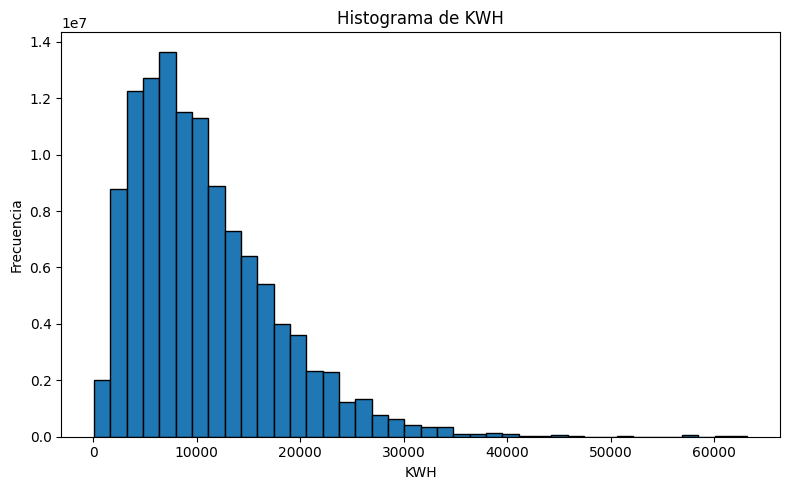

In [ ]:
weighted_histogram(data = data_2,
                   response="KWH",
                   weight='NWEIGHT',
                   bins=40,
                   log=False)

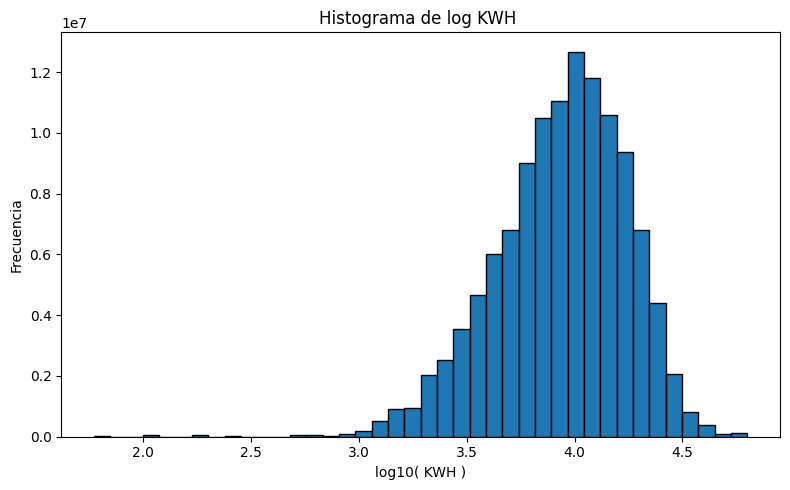

In [ ]:
weighted_histogram(data = data_2,
                   response="KWH",
                   weight='NWEIGHT',
                   bins=40,
                   log=True)

In [ ]:
data_2.loc[data_2["KWH"]< 10**2.5]

,KWH,NWEIGHT,ZONA_rural,DIVISION_new_england,DIVISION_middle_atlantic,DIVISION_east_north_central,DIVISION_west_north_central,DIVISION_south_atlantic,DIVISION_east_south_central,DIVISION_west_south_central,...,MADERA,SOLAR,OUTLET_auto_electrico,VENTANA_VIDRIO_doble_triple,MATERIAL_PARED_otro,MATERIAL_TECHO_otro,MATERIAL_MARCO_VENTANA_otro,CALEFACCION_TIPO_empotrado_no_electrico,CALEFACCION_TIPO_otro,TV_frecuencia_semana
824,59.078,17135.99319,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,77.0
2537,186.500,47442.56551,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,42.0
3364,109.157,71914.75706,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,35.0
4407,277.000,28463.11156,0,1,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0.0


In [ ]:
data_3 = data_2.loc[data_2["KWH"] >= 350].copy()
data_3["logKWH"] = np.log10(data_2["KWH"])
data_3 = data_3.drop(columns=["KWH"])

## IMPORTANCIA DE LOS PREDICTORES

Se elige el modelo random forest por su resistencia a los valores atípicos, al sobreajuste y a su capacidad de detectar relaciones no lineales.
Además, no requiere de configurar casi ningún hiperparametro y funciona bien con los valores por defecto.

Este modelo permite evaluar la importancia de cada predictor comparando la performance del modelo cuando la variable es utilizada vs cuando no es utilizada.

Por último brinda una estimación del R2.


Observamos que la cantidad de luces en el exterior, el uso semanal del lavarropa, el uso de electricidad para calefaccionar y calentar agua son los principales predictores.

R²   : 0.665
MAD  : 0.10
RMSE : 0.17


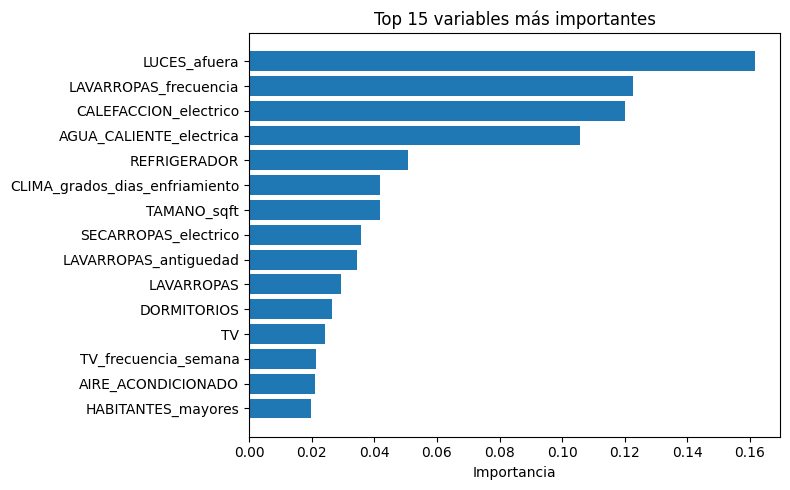

                                    Variable  Importance
110                             LUCES_afuera    0.161504
69                     LAVARROPAS_frecuencia    0.122706
135                    CALEFACCION_electrico    0.120083
100                  AGUA_CALIENTE_electrica    0.105604
37                              REFRIGERADOR    0.050656
..                                       ...         ...
160                      MATERIAL_PARED_otro    0.000000
161                      MATERIAL_TECHO_otro    0.000000
162              MATERIAL_MARCO_VENTANA_otro    0.000000
163  CALEFACCION_TIPO_empotrado_no_electrico    0.000000
164                    CALEFACCION_TIPO_otro    0.000000

[166 rows x 2 columns]


In [ ]:
importance = random_forest_importance(
    data = data_3,
    response="logKWH",
    weight="NWEIGHT",
    min_node_size=35,
    max_depth=8,
    n_trees=1000,
    top_n=15,
    random_state=456,
    permutation=False,
)

print(importance)


In [ ]:
print(importance.head(50))

                                      Variable  Importance
110                               LUCES_afuera    0.161504
69                       LAVARROPAS_frecuencia    0.122706
135                      CALEFACCION_electrico    0.120083
100                    AGUA_CALIENTE_electrica    0.105604
37                                REFRIGERADOR    0.050656
11              CLIMA_grados_dias_enfriamiento    0.041741
21                                 TAMANO_sqft    0.041718
76                        SECARROPAS_electrico    0.035830
75                       LAVARROPAS_antiguedad    0.034489
67                                  LAVARROPAS    0.029227
120                                DORMITORIOS    0.026402
77                                          TV    0.024345
165                       TV_frecuencia_semana    0.021455
123                         AIRE_ACONDICIONADO    0.020996
143                         HABITANTES_mayores    0.019674
39                                     FREEZER    0.0181

## PRINCIPALES VARIABLES NUMÉRICAS

Se analizan una a una las variables numéricas de mayor importancia, tanto en disribución (histograma) como su consumo mediano. Para ambas variables se utilizan los pesos muestrales.

### Luces exterior

Logaritmo linealiza la relación.

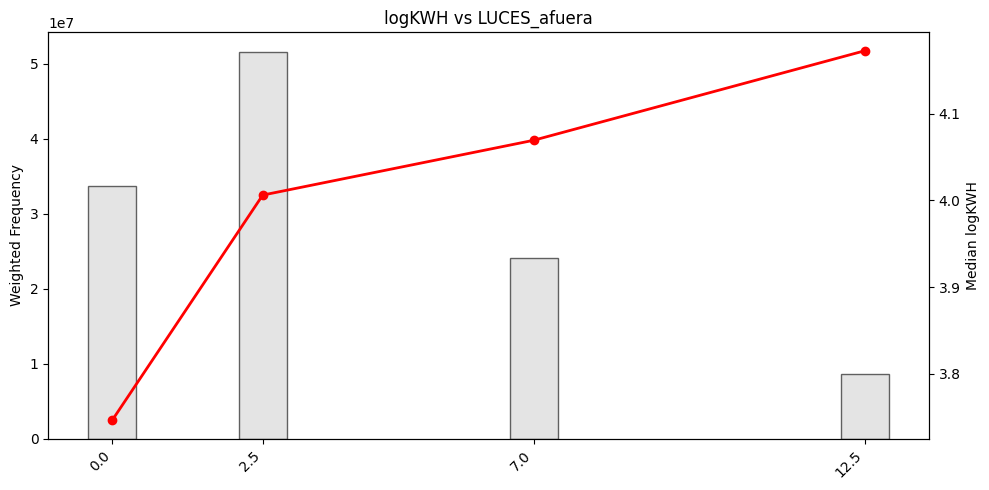

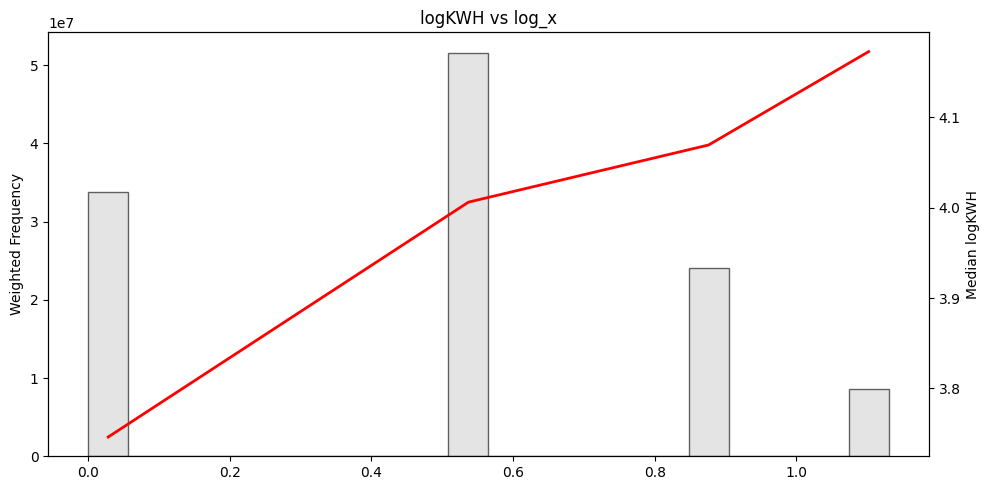

In [ ]:
combo_plot(data = data_3,
           response= "logKWH",
           x= 'LUCES_afuera',
           weight= 'NWEIGHT',
           type="auto", bins=20 )

data_3['LUCES_afuera_log'] = np.log10( 1 + data_3['LUCES_afuera'] )

combo_plot(data = data_3,
           response= "logKWH",
           x= 'LUCES_afuera_log',
           weight= 'NWEIGHT',
           type="continuous", bins=20)

data_3 = data_3.drop(columns=["LUCES_afuera_log"])


### Cantidad de lavados semanales

Nuevamente el logaritmo linealiza la relación.

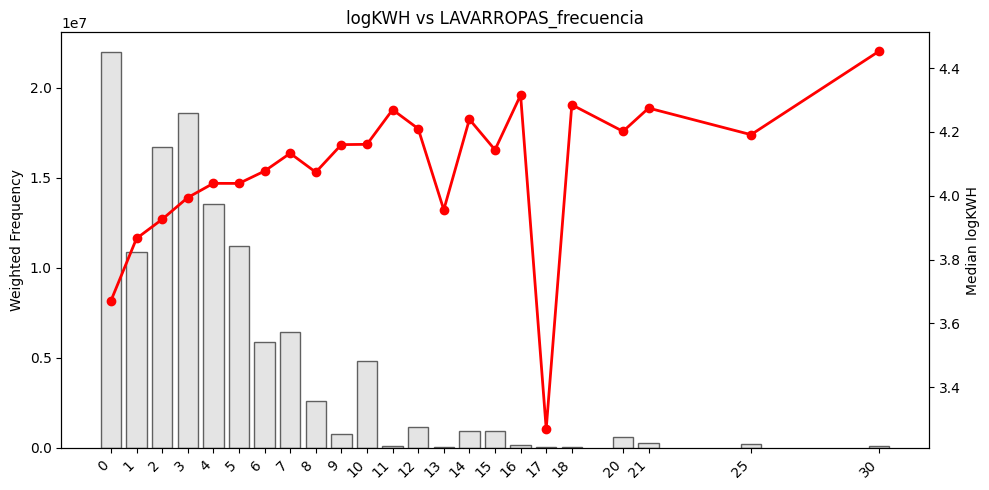

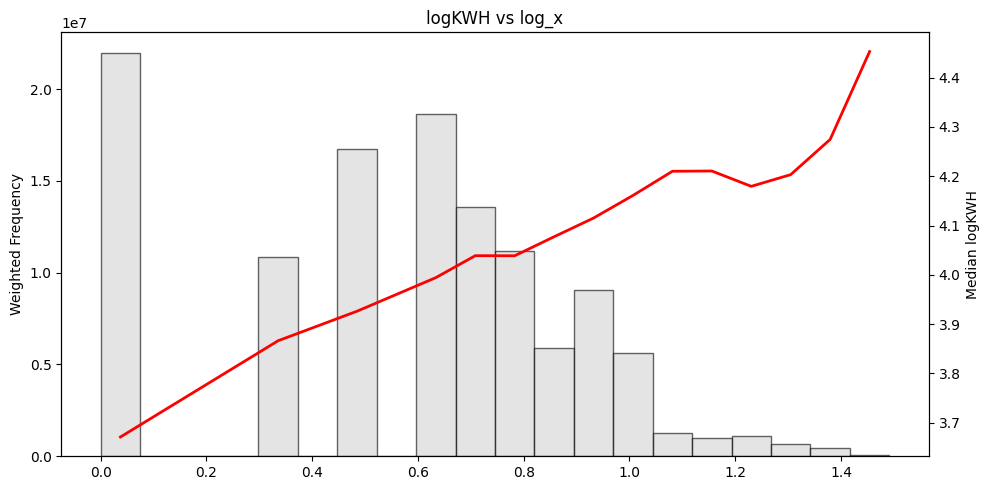

In [ ]:
combo_plot(data = data_3,
           response= "logKWH",
           x= 'LAVARROPAS_frecuencia',
           weight= 'NWEIGHT',
           type="auto", bins=20 )

data_3['LAVARROPAS_frecuencia_log'] = np.log10( 1 + data_3['LAVARROPAS_frecuencia'] )

combo_plot(data = data_3,
           response= "logKWH",
           x= 'LAVARROPAS_frecuencia_log',
           weight= 'NWEIGHT',
           type="continuous", bins=20)

data_3 = data_3.drop(columns=["LAVARROPAS_frecuencia_log"])


### dIas-grado de enfriamiento

A diferencia de las demás variables, esta parece dividir a los hogares en

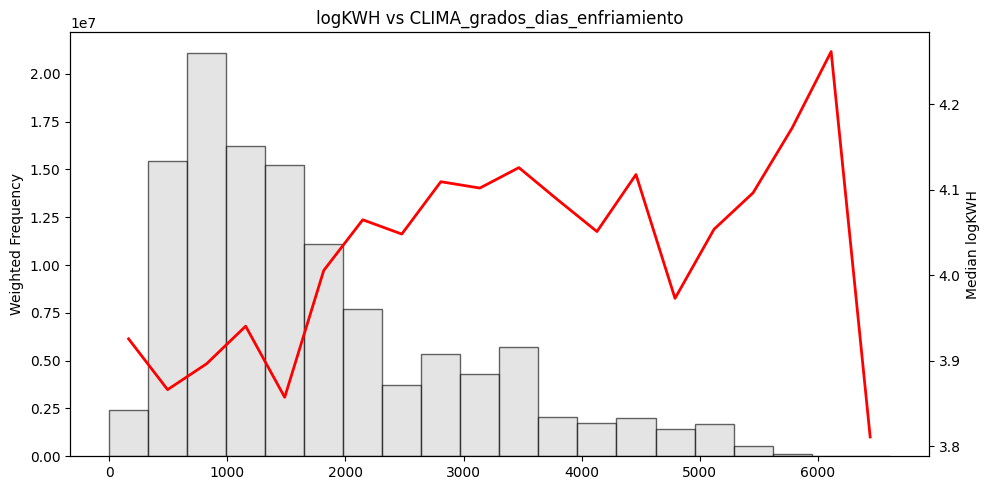

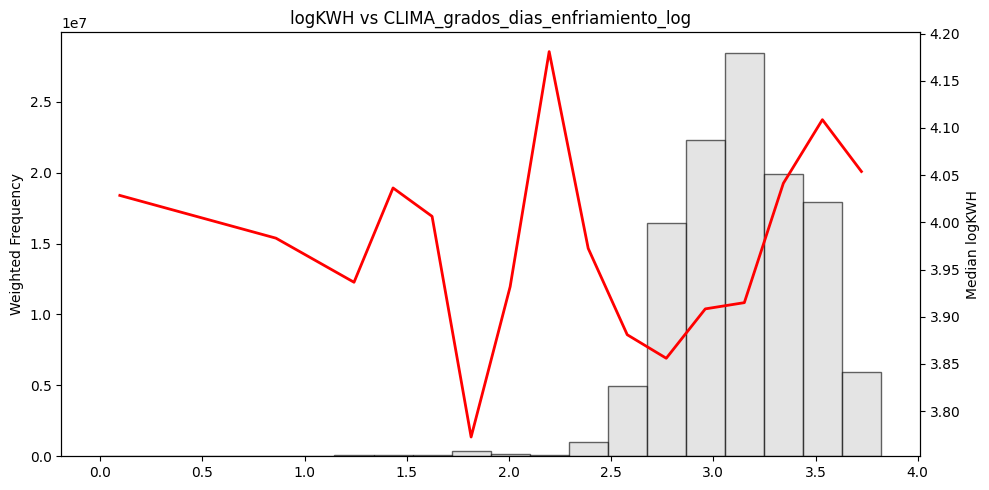

In [ ]:

combo_plot(data = data_3,
           response= "logKWH",
           x= 'CLIMA_grados_dias_enfriamiento',
           weight= 'NWEIGHT',
           type="continuous", bins=20,  )

data_3['CLIMA_grados_dias_enfriamiento_log'] = np.log10( 1 + data_3['CLIMA_grados_dias_enfriamiento'] )

combo_plot(data = data_3,
           response= "logKWH",
           x= 'CLIMA_grados_dias_enfriamiento_log',
           weight= 'NWEIGHT',
           type="continuous", bins=20 )

data_3 = data_3.drop(columns=["CLIMA_grados_dias_enfriamiento_log"])


### Cantidad de refrigeradores

Nuevamente el logaritmo linealiza la relación.

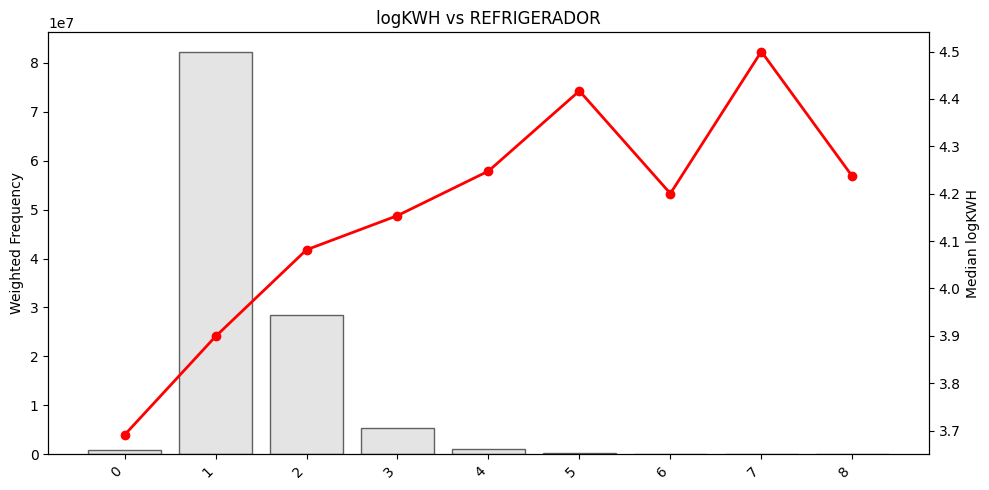

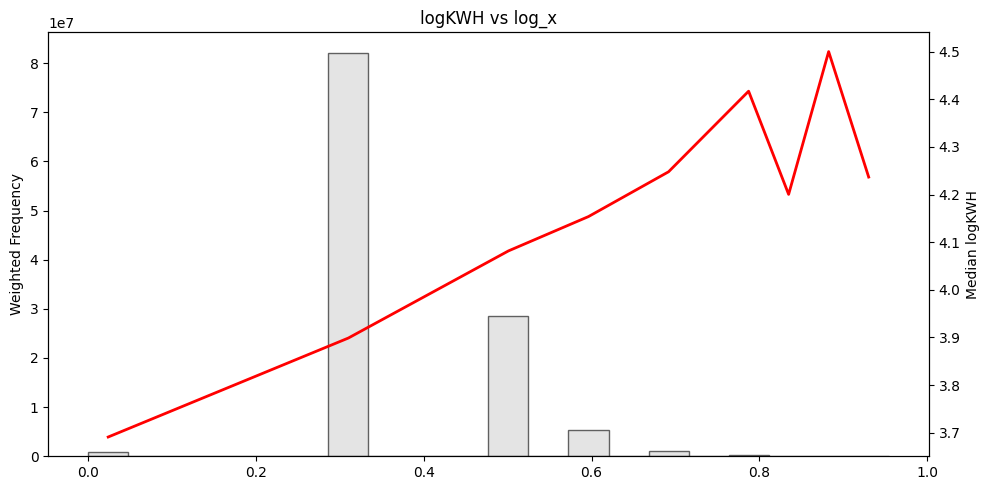

In [ ]:
combo_plot(data = data_3,
           response= "logKWH",
           x= 'REFRIGERADOR',
           weight= 'NWEIGHT',
           type="auto", bins=20 )

data_3['REFRIGERADOR_log'] = np.log10( 1 + data_3['REFRIGERADOR'] )

combo_plot(data = data_3,
           response= "logKWH",
           x= 'REFRIGERADOR_log',
           weight= 'NWEIGHT',
           type="continuous", bins=20)

data_3 = data_3.drop(columns=["REFRIGERADOR_log"])


### Tamaño de la vivienda

Nuevamente el logaritmo linealiza la relación.

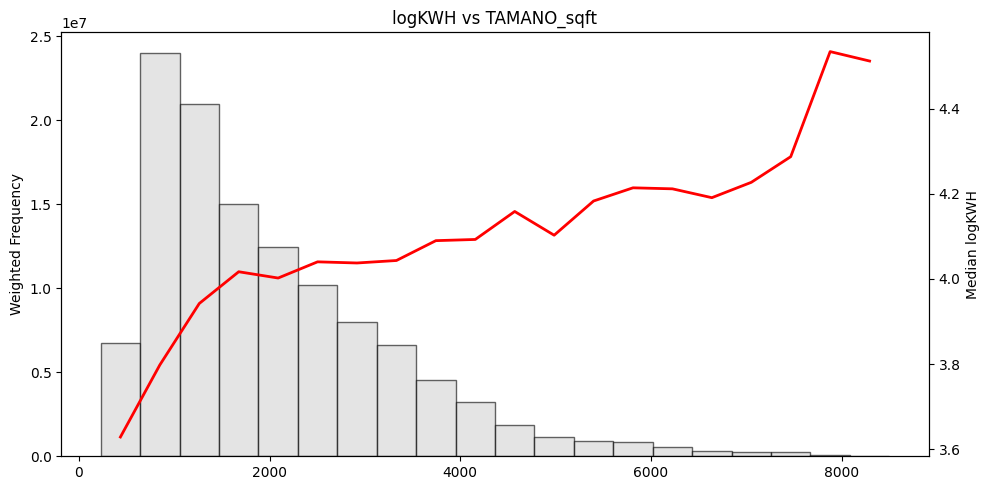

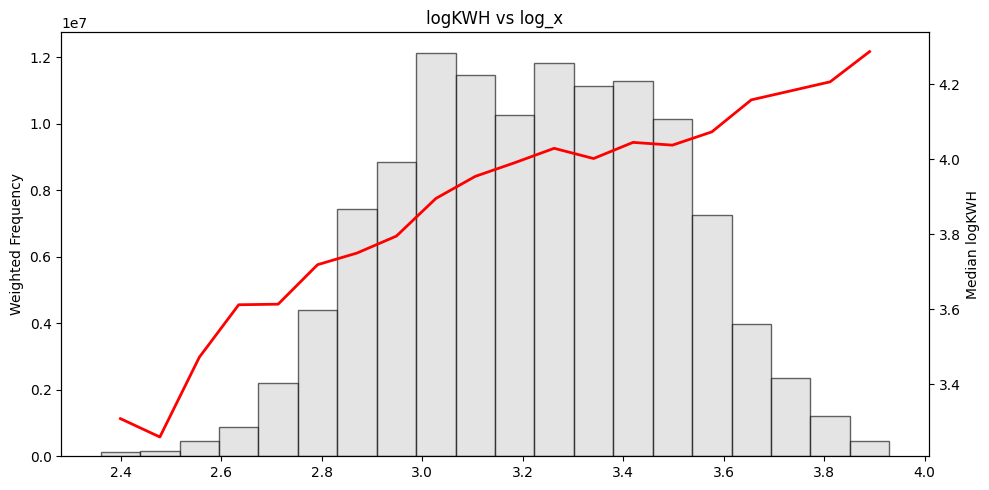

In [ ]:
combo_plot(data = data_3,
           response= "logKWH",
           x= 'TAMANO_sqft',
           weight= 'NWEIGHT',
           type="auto", bins=20 )

data_3['TAMANO_sqft_log'] = np.log10( 1 + data_3['TAMANO_sqft'] )

combo_plot(data = data_3,
           response= "logKWH",
           x= 'log_x',
           weight= 'NWEIGHT',
           type="continuous", bins=20)


data_3 = data_3.drop(columns=["TAMANO_sqft_log"])


## PRINCIPALES VARIABLES CATEGÓRICAS

Se presenta una tabla con el consumo mediano para cada grupo.
Podemos ver diferencias en el consumo de entre el 20 y 30%

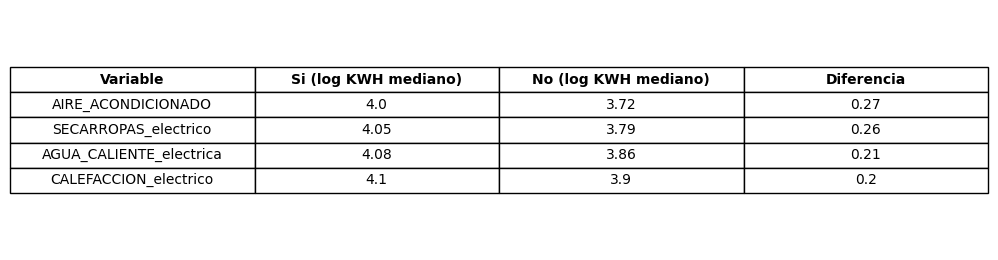

,Variable,Si (log KWH mediano),No (log KWH mediano),Diferencia
0,AIRE_ACONDICIONADO,3.995543,3.720821,0.274723
1,SECARROPAS_electrico,4.051148,3.787725,0.263423
2,AGUA_CALIENTE_electrica,4.075328,3.862901,0.212427
3,CALEFACCION_electrico,4.095024,3.896692,0.198333


In [ ]:
vars = ['CALEFACCION_electrico', 'AGUA_CALIENTE_electrica','SECARROPAS_electrico', 'AIRE_ACONDICIONADO']

binary_variable_summary(
    data = data_3,
    variables = vars,
    response = "logKWH",
    weights ="NWEIGHT",
    figsize=(8, 0.45),
    decimals=2
)



## TRANSFORMACIONES

Resume los cambios de esta sección:
- Filtra los KWH superiores a 350.
- Aplica logaritmo a la respuesta.
- Aplica logaritmo a las variables numéricas

In [20]:
data_4 = data_2.loc[data_2["KWH"] >= 350].copy()
data_4["logKWH"] = np.log10(data_2["KWH"])
data_4 = data_4.drop(columns=["KWH"])

vars = [ 'LUCES_afuera', 'LAVARROPAS_frecuencia', 'REFRIGERADOR', 'TAMANO_sqft',
        'LAVARROPAS_antiguedad', 'DORMITORIOS', 'TV', 'TV_frecuencia_semana',
        'LUCES_4_horas', 'VENTANAS', 'BANOS', 'AGUA_CALIENTE_tamano', 'BANOS',
         'INGRESO_per_capita', 'LUCES', 'LAVAVAJILLAS_frecuencia',
        'AIRE_ACONDICIONADO_antiguedad', 'SMARTPHONES', 'HORNO_horno_frecuencia',
        'HABITANTES_menores', 'ANTIGUEDAD',
        'MICROONDAS_frecuencia', 'HORNO_hornalla_frecuencia',
        'TV_tamano',
        'HABITANTES_mayores', 'HORNO_horno_otros_frecuencia',
        'LUCES_incandescentes_porcentaje',
        'ELECTRODOMESTICOS_BAJO_CONSUMO_porcentaje', 'COMPUTADORA_ESCRITORIO',
         'FREEZER'  ,           'PISCINA_meses' , 'CLIMA_grados_dias_calefaccion',
         'CLIMA_grados_dias_enfriamiento']




for var in vars:
    data_4[var + "_log"] = np.log10( 1 + data_4[var])


data_4 = data_4.drop(columns=vars)







# ETAPA 3: SELECCIÓN DE MODELOS

Se comparan a continuación modelos random forest, lightxgboost y regresión lineal. Los primeros dos son presentados con diversos hiperparámetros. Se utiliza validación cruzada para evitar sobreajustes y los pesos muestrales para mantener la muestra representativa de la población.

Pese a ser el modelo más sencillo, regresión lineal muestra  al mejor modelo (R2 de 0.66).

In [ ]:
models = {
    "Linear Regression": linear_regression,
    "Random Forest 6": random_forest_6,
    "Random Forest 8": random_forest_8,
    "Random Forest 10": random_forest_10,
    "LightGBM 0.001": lightgbm_001,
    "LightGBM 0.01": lightgbm_01,
    "LightGBM 0.05": lightgbm_05,
    "LightGBM 0.10": lightgbm_10,
}

results = cross_validation(
    data=data_3,
    kfolds=20,
    seed=1234,
    list_of_models=models,
    response="logKWH",
    weight="NWEIGHT",
)

print(results)

               Model  Median_R2  Median_MAD
0  Linear Regression   0.662895    0.102549
1      LightGBM 0.05   0.654313    0.102151
2      LightGBM 0.01   0.653975    0.097525
3      LightGBM 0.10   0.639787    0.104266
4   Random Forest 10   0.589376    0.116274
5    Random Forest 8   0.585117    0.118356
6    Random Forest 6   0.566364    0.121352
7     LightGBM 0.001   0.349404    0.167467


### Seleccion Lasso

En primera instancia se prueban diversos penalizadores (alfa) durante una regresión Lasso. Esto permite elegir el parámetro optimo para mantener un buen poder predictivo (R2, error absoluto mediano) y un modelo parsimonioso (menor número de parámetros).

El modelo completo presenta un R2 de 0.65 y error mediano de 0.10 para 160 variables. Pero de solo 0.62 y 0.11 para 36 variables.

Una vez elegido el parámetro lasso se realizan 50 muestreos por bootstrap. Y se seleccionan aquellas variables que resultaron elegidas en al menos un 80% de los casos para un total de 29 variables.




       alpha  median_nonzero  median_r2  median_mad
0   0.000100             163   0.652310    0.103381
1   0.000127             161   0.652479    0.103192
2   0.000161             160   0.652683    0.103108
3   0.000204             158   0.652979    0.103303
4   0.000259             157   0.653351    0.103078
5   0.000329             156   0.653795    0.102830
6   0.000418             153   0.654311    0.102669
7   0.000530             149   0.654890    0.101983
8   0.000672             145   0.655582    0.101935
9   0.000853             140   0.656348    0.101923
10  0.001083             134   0.656897    0.101484
11  0.001374             126   0.657749    0.101388
12  0.001743             118   0.658330    0.101331
13  0.002212             111   0.658604    0.101492
14  0.002807             100   0.658411    0.101829
15  0.003562              89   0.658048    0.101984
16  0.004520              79   0.656327    0.102253
17  0.005736              68   0.653289    0.103199
18  0.007279

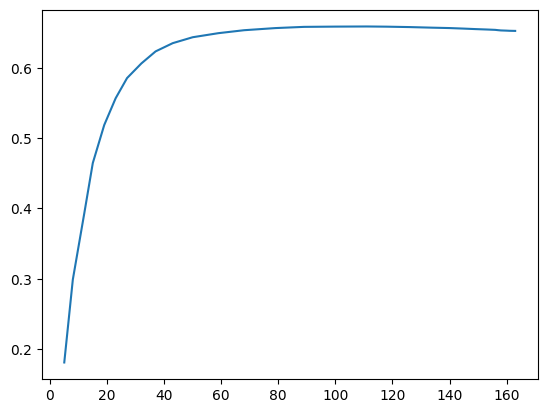

In [ ]:
results = []

alphas = np.logspace(-4, -1, 30)

for a in alphas:

    results.append(
        lasso_variable_selection(
            data_4,
            response="logKWH",
            weight="NWEIGHT",
            alpha=a,
            n_bootstraps=50,
            seed=123456789,
            variable_scores=False
        )
    )

results = pd.DataFrame(results)

print(results)
import matplotlib.pyplot as plt

plt.plot(results["median_nonzero"], results["median_r2"])
plt.show()

In [ ]:
alpha=0.015
results = lasso_variable_selection(
            data_4,
            response="logKWH",
            weight="NWEIGHT",
            alpha=alpha,
            n_bootstraps=50,
            seed=123456789,
            variable_scores=True
        )

selected_variables = results["variable_scores"][results["variable_scores"] > 40]
print(selected_variables.sort_values( ascending=False ) )

DIVISION_south_atlantic               50
DIVISION_east_south_central           50
SECARROPAS_electrico                  50
DIVISION_west_south_central           50
AIRE_ACONDICIONADO                    50
AGUA_CALIENTE_electrica               50
LUCES_afuera_log                      50
LAVARROPAS_frecuencia_log             50
AVISO_DESCONECCION                    50
CALEFACCION_electrico                 50
TV_log                                50
DORMITORIOS_log                       50
TAMANO_sqft_log                       50
REFRIGERADOR_log                      50
PISCINA_meses_log                     50
FREEZER_log                           50
HABITANTES_mayores_log                50
COMPUTADORA_ESCRITORIO_log            50
TV_frecuencia_semana_log              50
VENTANAS_log                          50
HABITANTES_menores_log                50
AGUA_CALIENTE_tamano_log              50
LAVAVAJILLAS_frecuencia_log           49
LUCES_4_horas_log                     49
VIVIENDA_departa

### Interacciones

Para las 29 variables seleccionadas se añaden todos los terminos de interaccion.
Luego se repiten los pasos anteriores:
- Busqueda del alpha que equilibre precisión y parsimonía. Nuevamente 0.015 es elegido.
- Selección por estabilidad.

In [29]:
data_5 = data_4.copy()

vars=[
'DIVISION_south_atlantic'   ,
'DIVISION_west_south_central',
'DIVISION_east_south_central' ,
'FREEZER_log'                  ,
'PISCINA_meses_log'             ,
'CALEFACCION_electrico'          ,
'AIRE_ACONDICIONADO'             ,
'SECARROPAS_electrico'           ,
'AGUA_CALIENTE_electrica'        ,
'REFRIGERADOR_log'               ,
'LAVARROPAS_frecuencia_log'      ,
'LUCES_afuera_log'               ,
'HABITANTES_mayores_log'             ,
'COMPUTADORA_ESCRITORIO_log'     ,
'VENTANAS_log'                   ,
'HABITANTES_menores_log'         ,
'AGUA_CALIENTE_tamano_log'       ,
'DORMITORIOS_log'                ,
'TAMANO_sqft_log'                ,
'TV_log'                         ,
'TV_frecuencia_semana_log'       ,
'AVISO_DESCONECCION'             ,
'LUCES_4_horas_log'              ,
'VIVIENDA_departamento_5'        ,
'TV_DECODIFICADOR_con_dvr'       ,
'BANOS_log'                      ,
'LAVAVAJILLAS_frecuencia_log'    ,
'CALEFACCION_TIPO_caldera'       ,
'ZONA_rural'    ,
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log'
       ]

data_5= data_5[vars]

## INTERACCIONES

for i in range(len(vars)-1):
  for j in range(i+1, len(vars)):
    data_5[vars[i]+'_X_'+vars[j]] = data_5[vars[i]] *data_5[vars[j]]


data_5["logKWH"]= data_4['logKWH']
data_5["NWEIGHT"]= data_4['NWEIGHT']

## EFECTOS CUADRATICOS

data_5['CLIMA_grados_dias_enfriamiento_log_2'] = data_5['CLIMA_grados_dias_enfriamiento_log']**2
data_5['CLIMA_grados_dias_calefaccion_log_2'] = data_5['CLIMA_grados_dias_calefaccion_log']**2
data_5['DORMITORIOS_log_2'] = data_5['DORMITORIOS_log']**2
data_5['HABITANTES_mayores_log_2'] = data_5[  'HABITANTES_mayores_log']**2
data_5['HABITANTES_menores_log_2'] = data_5[  'HABITANTES_menores_log']**2






# Para utilizar en la seleccion final
model_vars = {}
model_vars['EFECTOS PRINCIPALES']=  vars

In [30]:
results = []

alphas = np.logspace(-4, -1, 30)

for a in alphas:

    results.append(
        lasso_variable_selection(
            data_5,
            response="logKWH",
            weight="NWEIGHT",
            alpha=a,
            n_bootstraps=50,
            seed=123456789,
            variable_scores=False
        )
    )

results = pd.DataFrame(results)

print(results)
import matplotlib.pyplot as plt

plt.plot(results["median_nonzero"], results["median_r2"])
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.546e-02, tolerance: 5.001e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.105e-02, tolerance: 5.049e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.185e-02, tolerance: 5.363e

KeyboardInterrupt: 

In [31]:
alpha=0.015
results = lasso_variable_selection(
            data_5,
            response="logKWH",
            weight="NWEIGHT",
            alpha=alpha,
            n_bootstraps=50,
            seed=123456789,
            variable_scores=True
        )

selected_variables = results["variable_scores"][results["variable_scores"] > 40]
print(selected_variables.sort_values( ascending=False ) )

CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log        50
DORMITORIOS_log_X_CLIMA_grados_dias_enfriamiento_log             50
TAMANO_sqft_log_X_CLIMA_grados_dias_enfriamiento_log             49
AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log               48
AIRE_ACONDICIONADO_X_VENTANAS_log                                47
AGUA_CALIENTE_electrica_X_HABITANTES_mayores_log                 46
TV_log_X_TV_frecuencia_semana_log                                46
AIRE_ACONDICIONADO_X_HABITANTES_mayores_log                      45
SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log                 45
CALEFACCION_TIPO_caldera_X_CLIMA_grados_dias_enfriamiento_log    45
TV_log_X_LAVAVAJILLAS_frecuencia_log                             43
REFRIGERADOR_log_X_VENTANAS_log                                  42
dtype: int64


## Comparación final

Se comparan el modelo de Efectos Principales y el Modelo de Interacción anteriormente descritos.
Además, estudianto las variables seleccionadas en estos modelos se postulan tres nuevos modelos:
- Base que toma información sobre la cantidad de habitantes y dormitorios del hogar.
- Base + Consumo, que añade variables sobre los usos de la electricidad (uso de aire acondicionado, calefacción eléctrica y agua caliente electrica).
- Base + Consumo detallado, que expande sobre las anteriores, por ejemplo en la cantidad de lavados semanales, horas de televisión, etc.

| Modelo | Descripción | Variables | R2 | MAE-50% | MAE-80% | MAE-90% | MAE-95%|
| - | - | - | - | ---- | ---- | - | -|
| Base | Información básica sobre el hogar | 5 | 28% | 16% | 31% | 39% | 47% |
| Base + Consumo | Información básica sobre el hogar más usos generales de electricidad (cocinar, calefacción, etc) |9|  53% | 12% | 25% | 32% | 40% |
| Base + Consumo detallado | Información básica sobre el hogar más usos y habitos de la electricidad (cantidad de televisores, cantidad de lavados, etc) |17|  62% | 11% | 22% | 29% | 37% |
 | Efectos principales | Mejor modelo con las variables elegidas por Lasso | 27 | 64% |11% | 21% |28% |  33%|
 |Interacción| Mejor modelo elegido por Lasso incluyendo interacciones.|18 |58% | 11%| 23%| 30% |36% |




- El modelo de interacción presentó un pobre desempeño, indicando un sobreajuste o inestabilidad en la selección.
- El modelo de efectos principales marca un tope al que apuntar: 62% de R2 con error mediano del 11%.
- El modelo de Base + Consumo detallado alcanza este tope pero con muchas menos variables:  17 contra las 27.
- El modelo Base + Consumo resulta sumamente interesante. Sus errores no están lejos de los mejores modelos, presenta una mayor variabilidad al no contemplar los habitos de uso de la electricidad. Este comportamiento es deseable, entendiendo al error como las diferencias en los habitos de los usuarios.
- Finalmente el modelo base presenta un R2 mucho menor que el resto, y un mayor error. Este modelo busca capturar el consumo promedio para hogares en base a su tamaño y cantidad de habitantes, sin embargo no tiene en cuenta un factor fundamental: las tecnologías con la que cuenta el hogar (Calefacción a gas o electricidad, aire acondicionado o ventiladores, cocina a gas o electrica, etc).


Conclusión:
- El modelo Base + Consumo permite comparar una vivienda con otra del mismo tamaño, cantidad habitantes, región y tecnología. Volviendola ideal para medir la eficiencia y el perfil de consumo de un hogar.
- El modelo Base + Consumo detallado permite una estimación levemente más precisa del cosumo de un hogar. Además de dar lugar a los calculos de otros modelos (ETAPA:5).


In [33]:
model_vars={}

model_vars['base'] = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'HABITANTES_mayores_log_X_HABITANTES_menores_log',
             ]


model_vars['base_consumo'] =[
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'HABITANTES_mayores_log_X_HABITANTES_menores_log',

    'AIRE_ACONDICIONADO'             ,
    'AIRE_ACONDICIONADO_X_VENTANAS_log'             ,
    'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'             ,


    'CALEFACCION_electrico'          ,
    'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'                   ,
    'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'          ,

    'AGUA_CALIENTE_electrica',

   # 'SECARROPAS_electrico'

    ]

model_vars['base_consumo_habitos'] =[
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
#    'HABITANTES_mayores_log_X_HABITANTES_menores_log',
    'AIRE_ACONDICIONADO'             ,
   'AIRE_ACONDICIONADO_X_VENTANAS_log'             ,
    'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'             ,


    'CALEFACCION_electrico'          ,
    'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'                   ,
    'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'          ,

    'AGUA_CALIENTE_electrica',
    'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'               ,

    'SECARROPAS_electrico',
    'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'                              ,

 #   'PISCINA_meses_log' ,
    'REFRIGERADOR_log'               ,
    'FREEZER_log'                  ,


    'TV_log_X_TV_frecuencia_semana_log',
    'TV_log',
    'TV_frecuencia_semana_log',


    'LUCES_afuera_log'               ,
    'LUCES_afuera_log_X_LUCES_4_horas_log'               ,
    'LUCES_4_horas_log'


    ]




model_vars['EFECTOS_PRINCIPALES'] = [
'DIVISION_south_atlantic'   ,
'DIVISION_west_south_central',
'DIVISION_east_south_central' ,
'FREEZER_log'                  ,
'PISCINA_meses_log'             ,
'CALEFACCION_electrico'          ,
'AIRE_ACONDICIONADO'             ,
'SECARROPAS_electrico'           ,
'AGUA_CALIENTE_electrica'        ,
'REFRIGERADOR_log'               ,
'LAVARROPAS_frecuencia_log'      ,
'LUCES_afuera_log'               ,
'HABITANTES_mayores_log'             ,
'COMPUTADORA_ESCRITORIO_log'     ,
'VENTANAS_log'                   ,
'HABITANTES_menores_log'         ,
'AGUA_CALIENTE_tamano_log'       ,
'DORMITORIOS_log'                ,
'TAMANO_sqft_log'                ,
'TV_log'                         ,
'TV_frecuencia_semana_log'       ,
'AVISO_DESCONECCION'             ,
'LUCES_4_horas_log'              ,
'VIVIENDA_departamento_5'        ,
'TV_DECODIFICADOR_con_dvr'       ,
'BANOS_log'                      ,
'LAVAVAJILLAS_frecuencia_log'    ,
'CALEFACCION_TIPO_caldera'       ,
'ZONA_rural'    ,
       'CLIMA_grados_dias_enfriamiento_log',
       'CLIMA_grados_dias_calefaccion_log'
       ]




model_vars['INTERACCION']= ['CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'             ,
       'DORMITORIOS_log_X_CLIMA_grados_dias_enfriamiento_log'    ,
        'TAMANO_sqft_log_X_CLIMA_grados_dias_enfriamiento_log'                  ,
        'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'               ,
        'AIRE_ACONDICIONADO_X_VENTANAS_log'      ,
        'AGUA_CALIENTE_electrica_X_HABITANTES_mayores_log'          ,
        'TV_log_X_TV_frecuencia_semana_log'                     ,
        'AIRE_ACONDICIONADO_X_HABITANTES_mayores_log'                               ,
        'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'                              ,
        'CALEFACCION_TIPO_caldera_X_CLIMA_grados_dias_enfriamiento_log'                    ,
        'TV_log_X_LAVAVAJILLAS_frecuencia_log' ,
        'REFRIGERADOR_log_X_VENTANAS_log'          ,
       ]


In [25]:



for model_name in list(model_vars.keys()):
  print(model_name)

  result = cross_validation_linear(
    data = data_5,
    response = "logKWH" ,
    predictors =model_vars[model_name] ,
    weight = "NWEIGHT",
    kfolds=100,
    seed=123981,
)
  print(result)

base
   Median_R2  Median_MAE   80%_MAE  90%_MAE   95%_MAE  Median_SE
0   0.285106    0.161041  0.305223  0.38708  0.473472   0.239609
base_consumo
   Median_R2  Median_MAE   80%_MAE   90%_MAE   95%_MAE  Median_SE
0   0.495709    0.130178  0.248285  0.333078  0.400122   0.201388
base_consumo_habitos
   Median_R2  Median_MAE   80%_MAE   90%_MAE   95%_MAE  Median_SE
0   0.615876     0.10951  0.216757  0.293936  0.364662   0.180297
EFECTOS_PRINCIPALES
   Median_R2  Median_MAE  80%_MAE   90%_MAE   95%_MAE  Median_SE
0    0.64397    0.104917  0.21013  0.280951  0.333586   0.174525
INTERACCION
   Median_R2  Median_MAE   80%_MAE   90%_MAE   95%_MAE  Median_SE
0   0.582911    0.112531  0.226292  0.304337  0.361966   0.184749


# ETAPA 4: DIAGNÓSTICO




                            WLS Regression Results                            
Dep. Variable:                 logKWH   R-squared:                       0.511
Model:                            WLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     422.4
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:20:38   Log-Likelihood:                 546.66
No. Observations:                5682   AIC:                            -1063.
Df Residuals:                    5667   BIC:                            -963.6
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

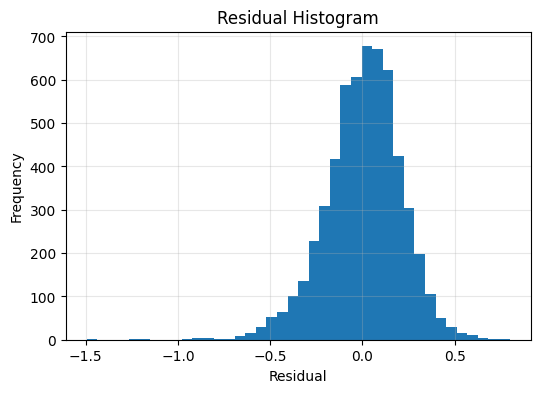

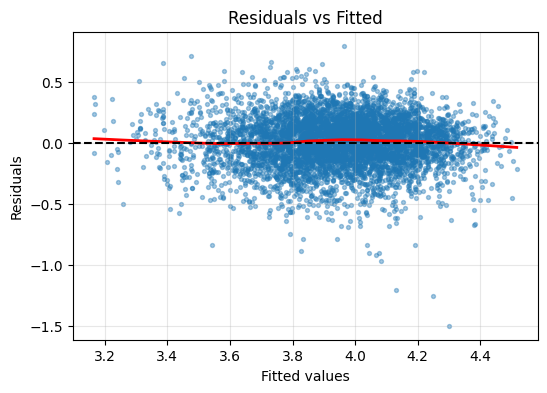

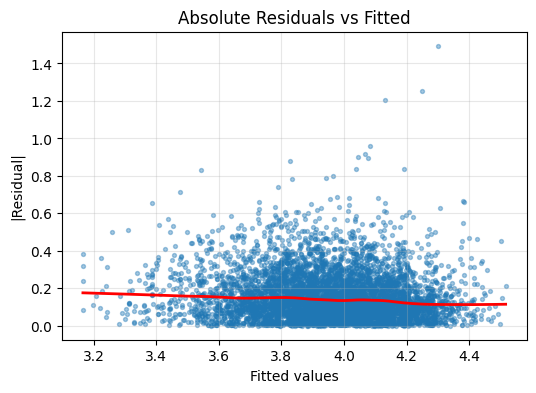

In [26]:
vars = model_vars['base_consumo']

residual_plot(
    data=data_5[vars + ['logKWH', 'NWEIGHT']],
    response = 'logKWH',
    weight = 'NWEIGHT'
)

                            WLS Regression Results                            
Dep. Variable:                 logKWH   R-squared:                       0.626
Model:                            WLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     395.3
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        06:03:03   Log-Likelihood:                 1313.9
No. Observations:                5682   AIC:                            -2578.
Df Residuals:                    5657   BIC:                            -2412.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

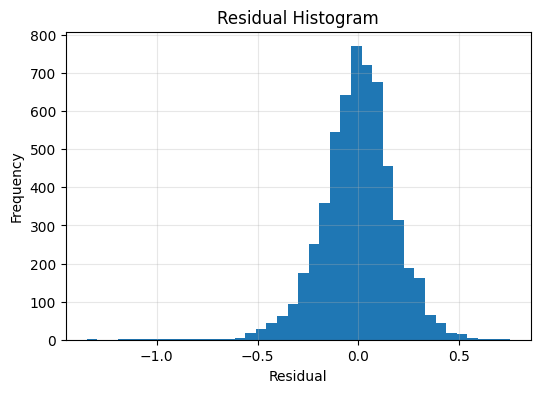

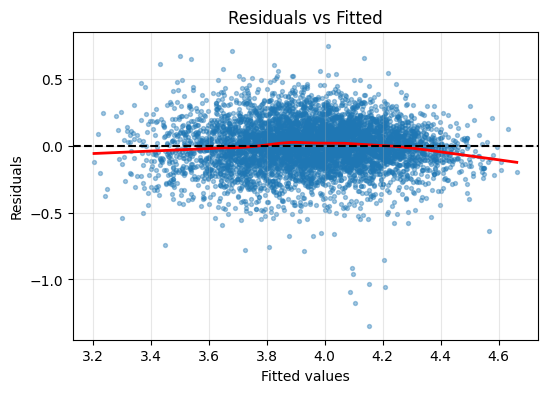

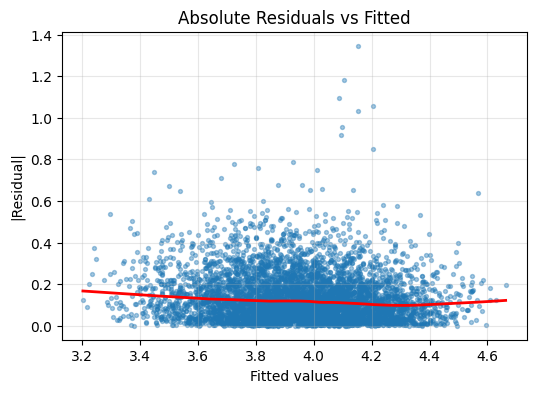

In [37]:
vars = model_vars['base_consumo_habitos']

residual_plot(
    data=data_5[vars + ['logKWH', 'NWEIGHT']],
    response = 'logKWH',
    weight = 'NWEIGHT'
)

# ETAPA 5: OTROS MODELOS

Hasta ahora el enfoque ha sido calcular el consumo total del hogar. Sin embargo también nos interesa encontrar las fuentes de ese consumo.

A continuación se presentan las variables disponibles y los percentiles 50, 75 y 95 de su consumo sobre el total.

Observamos que:
- Muchas variables poseen porcentaje 0 o muy bajo para la mediana (50%). Esto implica una alta variabilidad en los tipos de consumo.
- Las siguientes categorías representan menos de un 10% del consumo total, aún en los casos más extremos:
```
FREEZER     -    COCINA          -    MICROONDAS       -    LAVARROPAS     
LAVAPLATOS  -    TURBINAS_CALOR  -    TURBINAS_FRIO    -    VENTILADORES
HUMIFICADOR -    PISCINAS        -    BOMBAS_SAUNA     -    SAUNA
ENFRIAMIENTO_POR_EVAPORADOR      -    DESHUMIFICADOR     
```
Exceptuando a COCINA se opta por combinar las demás variables, resultando en estas categorías finales:
```
AGUA_SANITARIA
AIRE_ACONDICIONADO
CALEFACCION
COCINA : (COCINA + MICROONDAS)
ILUMINACIÓN
LAVADO: (LAVARROPA + SECARROPAS)
REFRIGERACION : (FREEZER + REFRIGERADORES)
TV
OTROS : (OTROS + LAVAPLATOS  +    TURBINAS_CALOR  +    TURBINAS_FRIO + VENTILADORES + HUMIFICADOR +    PISCINAS  +    BOMBAS_SAUNA     +    SAUNA+
ENFRIAMIENTO_POR_EVAPORADOR  +    DESHUMIFICADOR    )

```


In [ ]:
vars =[
    'KWHSPH',
'KWHCOL',
'KWHWTH',
'KWHRFG',
'KWHFRZ',
'KWHCOK',
'KWHMICRO',
'KWHCW',
'KWHCDR',
'KWHDWH',
'KWHLGT',
'KWHTVREL',
'KWHAHUHEAT',
'KWHAHUCOL',
'KWHEVAPCOL',
'KWHCFAN',
'KWHDHUM',
'KWHHUM',
'KWHPLPMP',
'KWHHTBPMP',
'KWHHTBHEAT',
 'KWHNEC']


print("Variable", "50%", "75%", "95%")

for var in vars:
  aux = 100 * data[var] / data['KWH']
  perc = np.percentile(aux, [50, 75 , 95]).astype(int)
  print(var,"    |" ,perc[0], perc[1], perc[2])



Variable 50% 75% 95%
KWHSPH     | 0 18 46
KWHCOL     | 12 23 44
KWHWTH     | 0 22 40
KWHRFG     | 7 12 22
KWHFRZ     | 0 2 8
KWHCOK     | 1 2 5
KWHMICRO     | 0 1 4
KWHCW     | 0 0 1
KWHCDR     | 3 7 15
KWHDWH     | 0 1 2
KWHLGT     | 8 15 30
KWHTVREL     | 6 10 20
KWHAHUHEAT     | 0 2 7
KWHAHUCOL     | 0 1 2
KWHEVAPCOL     | 0 0 0
KWHCFAN     | 0 2 6
KWHDHUM     | 0 0 10
KWHHUM     | 0 0 4
KWHPLPMP     | 0 0 6
KWHHTBPMP     | 0 0 0
KWHHTBHEAT     | 0 0 0


## PREPARA LOS DATASETS DE CONSUMO

In [47]:
data_consumo = data.copy()

respuestas = ['PER_AGUA_SANITARIA', 'PER_AIRE_ACONDICIONADO', 'PER_CALEFACCION', 'PER_COCINA',
'PER_REFRIGERACION' , 'PER_LAVADO'  , 'PER_ILUMINACION'  , 'PER_TV'  , 'PER_OTROS' , 'KWH'      ]

predictores = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'AIRE_ACONDICIONADO',
    'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'             ,
    'CALEFACCION_electrico'          ,
    'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'                   ,
    'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'          ,
    'AGUA_CALIENTE_electrica',
    'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'               ,
    'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'                  ,
    'REFRIGERADOR_log'               ,
    'FREEZER_log'                  ,
    'TV_log',
    'TV_frecuencia_semana_log',
    'TV_log_X_TV_frecuencia_semana_log',
    'LUCES_afuera_log'               ,
    'LUCES_afuera_log_X_LUCES_4_horas_log'               ,
    'LUCES_4_horas_log' ,
    'HORNO_electrico' # añadida para represenar el uso de la electricidad para cocinar
    ]

data_consumo['PER_AGUA_SANITARIA'] = data_consumo['KWHWTH'] / data_consumo['KWH']

data_consumo['PER_AIRE_ACONDICIONADO'] = data_consumo['KWHCOL'] / data_consumo['KWH']
data_consumo['PER_CALEFACCION'] = data_consumo['KWHSPH'] / data_consumo['KWH']
data_consumo['PER_COCINA'] = (data_consumo['KWHMICRO'] + data_consumo['KWHCOK']) / data_consumo['KWH']
data_consumo['PER_REFRIGERACION'] = (data_consumo['KWHRFG'] + data_consumo['KWHFRZ']) / data_consumo['KWH']
data_consumo['PER_LAVADO'] = (data_consumo['KWHCW'] + data_consumo['KWHCDR']) / data_consumo['KWH']

data_consumo['PER_ILUMINACION'] = data_consumo['KWHLGT'] / data_consumo['KWH']

data_consumo['PER_TV'] = data_consumo['KWHTVREL'] / data_consumo['KWH']
data_consumo['PER_OTROS'] = (data_consumo['KWHNEC'] + data_consumo['KWHHTBHEAT']
                             + data_consumo['KWHHTBPMP'] + data_consumo['KWHPLPMP']
                             + data_consumo['KWHHUM'] + data_consumo['KWHDHUM']
                              + data_consumo['KWHCFAN'] + data_consumo['KWHEVAPCOL']
                              + data_consumo['KWHAHUCOL'] + data_consumo['KWHAHUHEAT']
                             + data_consumo['KWHDWH']
            )/ data_consumo['KWH']





data_consumo['CLIMA_grados_dias_enfriamiento_log'] = np.log10(1 + data_2['CLIMA_grados_dias_enfriamiento'])
data_consumo['CLIMA_grados_dias_calefaccion_log'] = np.log10(1 + data_2['CLIMA_grados_dias_calefaccion'])
data_consumo['DORMITORIOS_log'] = np.log10(1 + data_2['DORMITORIOS'])
data_consumo['VENTANAS_log'] = np.log10(1 + data_2['VENTANAS'])
data_consumo['HABITANTES_mayores_log'] = np.log10(1 + data_2['HABITANTES_mayores'])
data_consumo['HABITANTES_menores_log'] = np.log10(1 + data_2['HABITANTES_menores'])

data_consumo['AIRE_ACONDICIONADO'] =data_2['AIRE_ACONDICIONADO']
data_consumo['AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'] = np.log10(1 + data_2['CLIMA_grados_dias_enfriamiento']) * data_2['AIRE_ACONDICIONADO']

data_consumo['CALEFACCION_electrico'] =  data_2['CALEFACCION_electrico']
data_consumo['CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'] = np.log10(1 + data_2['CLIMA_grados_dias_calefaccion']) * data_2['CALEFACCION_electrico']
data_consumo['VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'] = np.log10(1 + data_2['CLIMA_grados_dias_calefaccion']) *  np.log10(1 + data_2['VENTANAS'])

data_consumo['AGUA_CALIENTE_electrica'] =  data_2['AGUA_CALIENTE_electrica']
data_consumo['AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'] = np.log10(1 + data_2['AGUA_CALIENTE_tamano']) * data_2['AGUA_CALIENTE_electrica']


data_consumo['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'] = np.log10(1 + data_2['LAVARROPAS_frecuencia']) * data_2['SECARROPAS_electrico']

data_consumo['REFRIGERADOR_log'] = np.log10(1 + data_2['REFRIGERADOR'])
data_consumo['FREEZER_log'] = np.log10(1 + data_2['FREEZER'])

data_consumo['TV_log'] = np.log10(1 + data_2['TV'])
data_consumo['TV_frecuencia_semana_log'] = np.log10(1 + data_2['TV_frecuencia_semana'])
data_consumo['TV_log_X_TV_frecuencia_semana_log'] = np.log10(1 + data_2['TV']) *np.log10(1 + data_2['TV_frecuencia_semana'])


data_consumo['LUCES_afuera_log'] = np.log10(1 + data_2['LUCES_afuera'])
data_consumo['LUCES_4_horas_log'] = np.log10(1 + data_2['LUCES_4_horas'])
data_consumo['LUCES_afuera_log_X_LUCES_4_horas_log'] = np.log10(1 + data_2['LUCES_afuera']) *np.log10(1 + data_2['LUCES_4_horas'])

data_consumo['LUCES_afuera_log_X_LUCES_4_horas_log'] = np.log10(1 + data_2['LUCES_afuera']) *np.log10(1 + data_2['LUCES_4_horas'])

data_consumo['HORNO_electrico'] = (data['STOVENFUEL']==5).astype(int)

data_consumo = data_consumo.loc[data['KWH']>350]

data_consumo =data_consumo[predictores + respuestas + ['NWEIGHT']]








## ANALIZANDO EL CONSUMO POR CATEGORIAS

### Aguas Saniarias
Calentar agua para el lavado de plaotos, duchas, etc. Se observa una alta concencración en el valor 0, represenando aquellos que no utilizan calenadores electricos para el agua.

Se procede a eliminar a los hogares que no utilizan electricidad para calentar agua. Obeniendo un histograma asimétrico hacia la derecha.

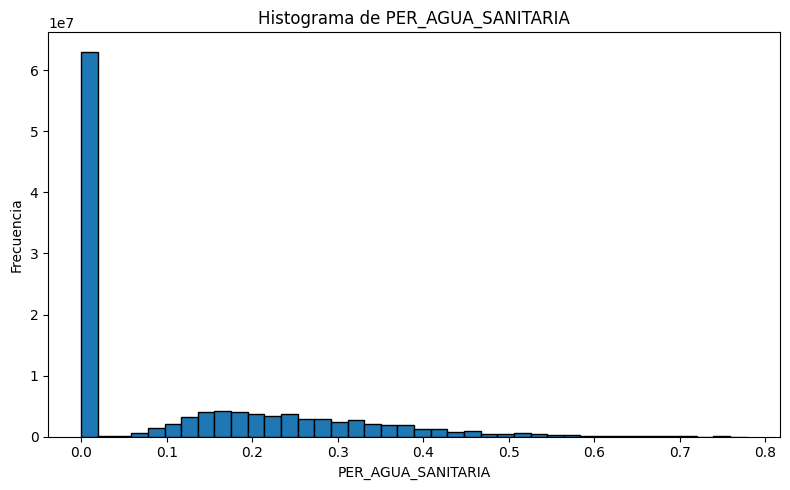

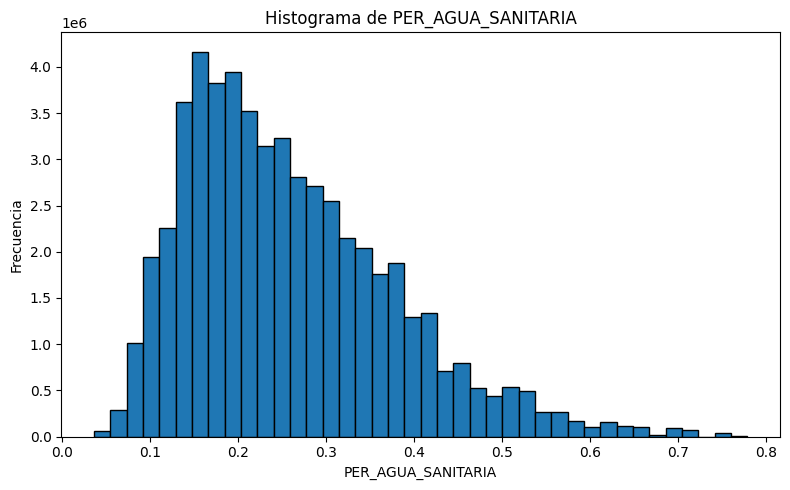

In [ ]:
weighted_histogram( data_consumo, 'PER_AGUA_SANITARIA', 'NWEIGHT')

weighted_histogram( data_consumo.loc[data_consumo['AGUA_CALIENTE_electrica']>0],
                   'PER_AGUA_SANITARIA', 'NWEIGHT')

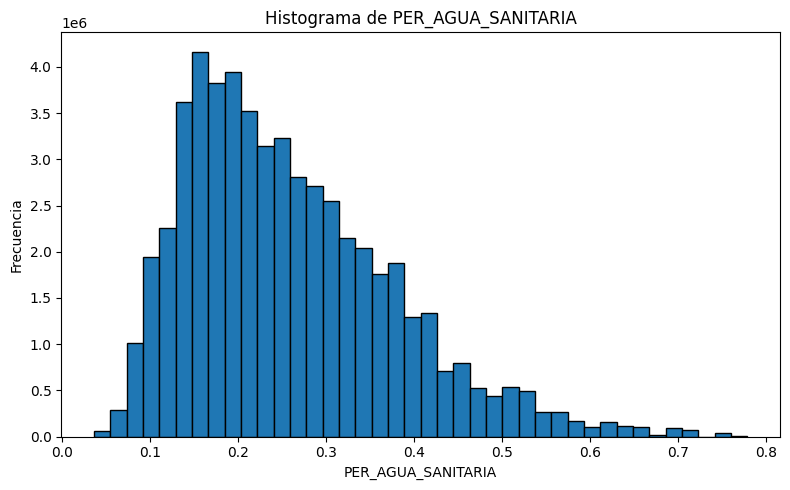

Aplicamos una regresión linea, pero encontramos que el modelo no predice bien los casos extremos (debajo de 10% de proporción) y tiene problemas de variancia no constante.

                            WLS Regression Results                            
Dep. Variable:     PER_AGUA_SANITARIA   R-squared:                       0.585
Model:                            WLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     203.1
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:24:29   Log-Likelihood:                 2861.8
No. Observations:                2611   AIC:                            -5686.
Df Residuals:                    2592   BIC:                            -5574.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

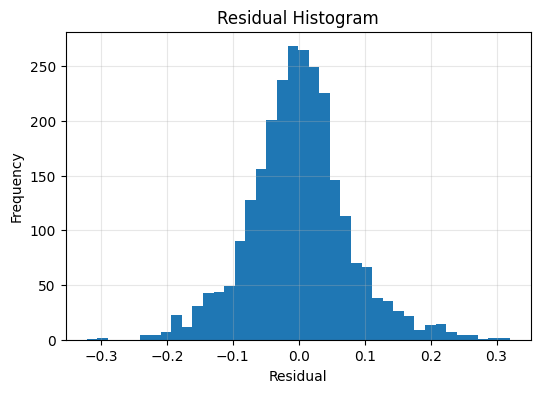

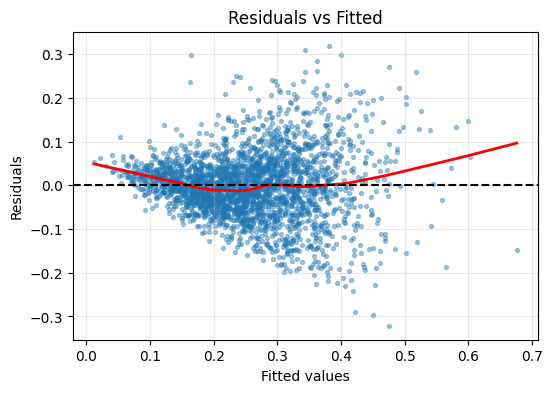

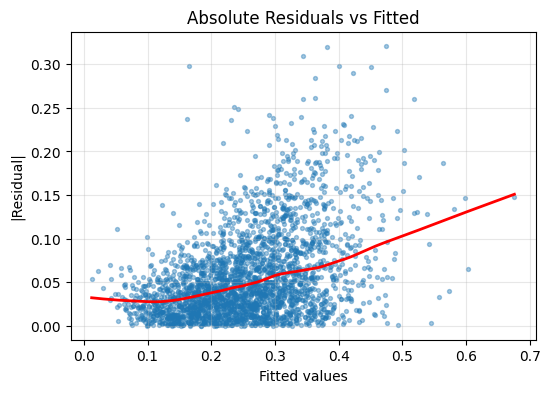

In [ ]:
residual_plot(
    data=data_consumo.loc[data_consumo['AGUA_CALIENTE_electrica']>0, predictores+[ 'PER_AGUA_SANITARIA','NWEIGHT']],
    response = 'PER_AGUA_SANITARIA',
    weight = 'NWEIGHT'
)

Debido a que la variable respuesta es una proporción (contenida en el inervalo 0 y 1) se propone utilizar la transformación logit. A continuación se presenan los resultados.

Se observa que el modelo esá bien especificado (buen ajuste) y los residuos presenan disribución aproximadamente normal. Sin embargo, la varianza no es constane, por lo que este modelo sirve para realizar predicciones puntuales aunque no intervalos.

                            WLS Regression Results                            
Dep. Variable:     PER_AGUA_SANITARIA   R-squared:                       0.608
Model:                            WLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     223.0
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:56:30   Log-Likelihood:                -1443.1
No. Observations:                2611   AIC:                             2924.
Df Residuals:                    2592   BIC:                             3036.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

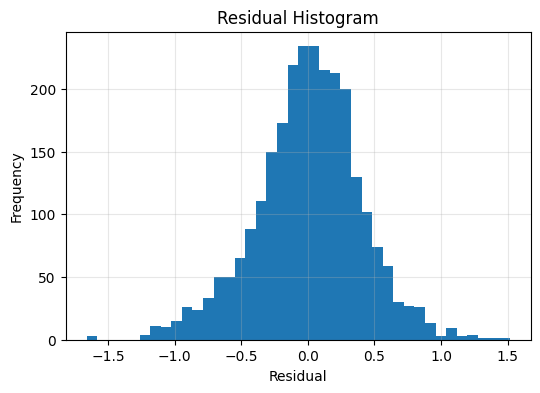

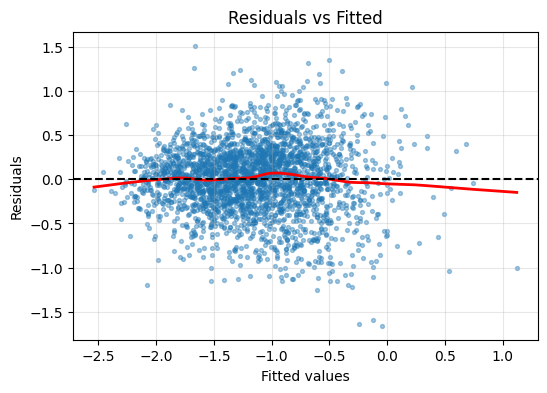

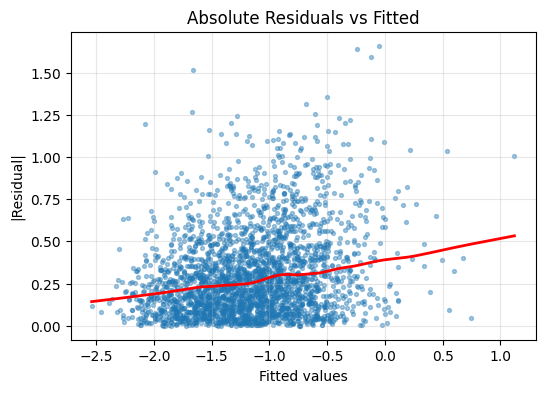

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['AGUA_CALIENTE_electrica']>0]
aux['PER_AGUA_SANITARIA'] = np.log( aux['PER_AGUA_SANITARIA'] / (1-aux['PER_AGUA_SANITARIA']))
aux = aux[ predictores+[ 'PER_AGUA_SANITARIA','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'PER_AGUA_SANITARIA',
    weight = 'NWEIGHT'
)

### Aire Acondicionado

Nuevamene notamos la concentración de valores en cero, se decide eliminar los hogares sin aire acondicionado.

Luego se ajusta un modelo logit que parece ajustar bien.

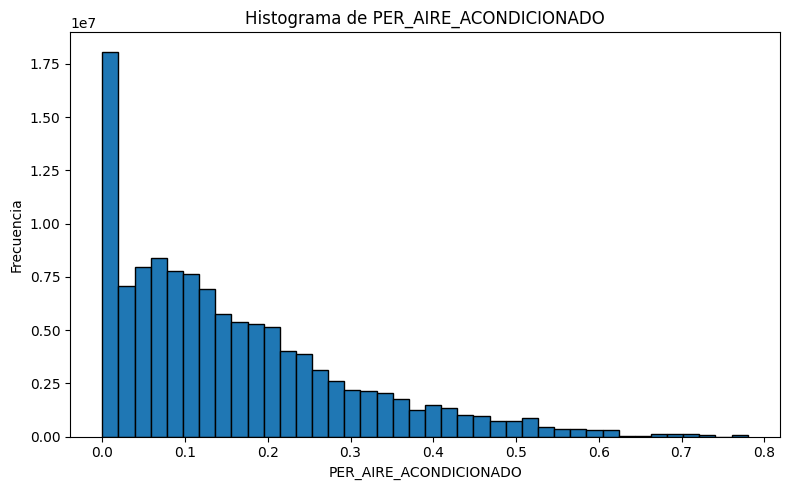

In [ ]:
weighted_histogram( data_consumo,
                   'PER_AIRE_ACONDICIONADO', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.731
Model:                            WLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     706.1
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:48:13   Log-Likelihood:                -4193.1
No. Observations:                4945   AIC:                             8426.
Df Residuals:                    4925   BIC:                             8556.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

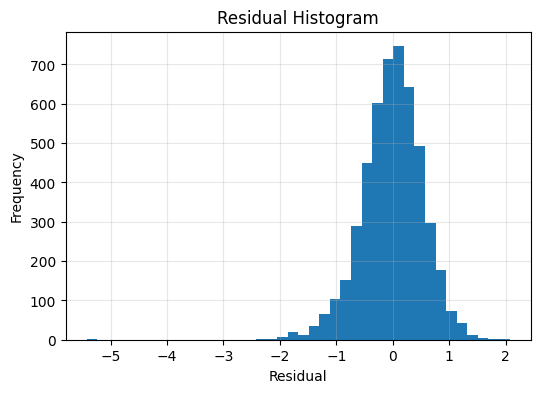

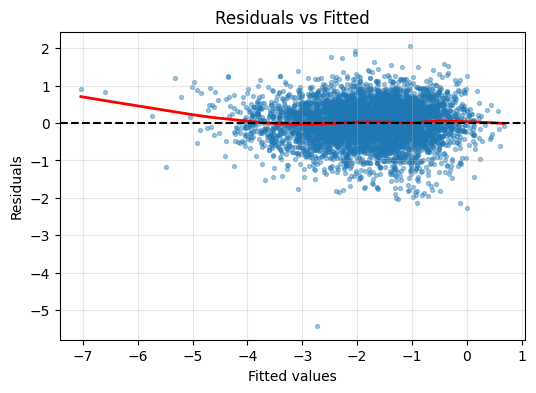

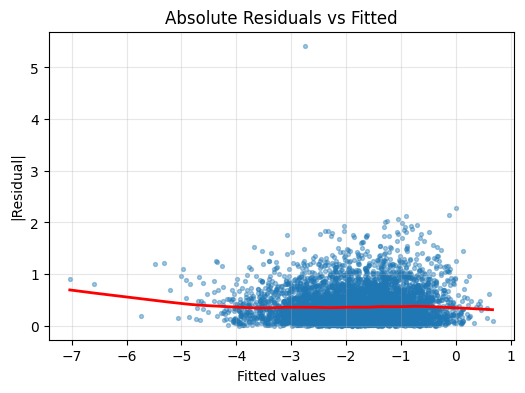

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log']>0]
aux['target'] = np.log( aux['PER_AIRE_ACONDICIONADO'] / (1-aux['PER_AIRE_ACONDICIONADO']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### Calefacción

Nuevamene notamos la concentración de valores en cero, se decide eliminar los hogares sin calefacción eléctrica.

Luego se ajusta un modelo logit que parece ajustar bien.

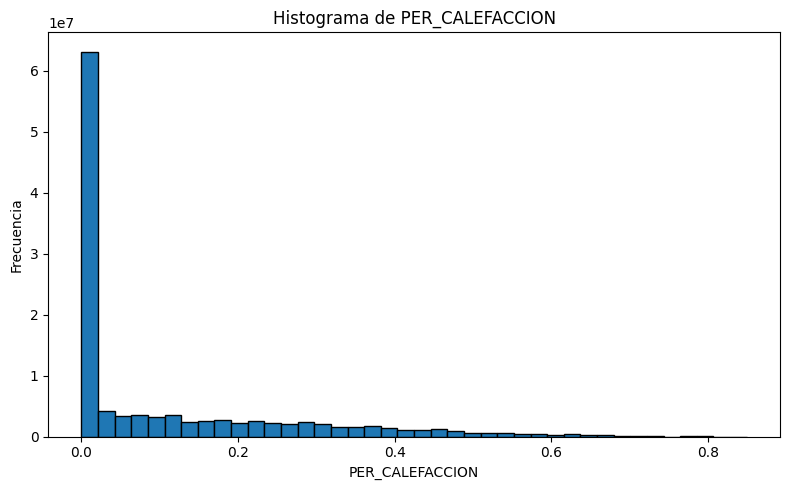

In [ ]:
weighted_histogram( data_consumo,
                   'PER_CALEFACCION', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.656
Model:                            WLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     206.3
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        03:31:46   Log-Likelihood:                -2134.7
No. Observations:                1970   AIC:                             4307.
Df Residuals:                    1951   BIC:                             4414.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

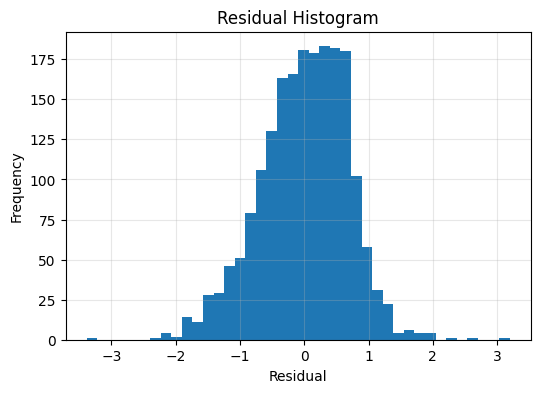

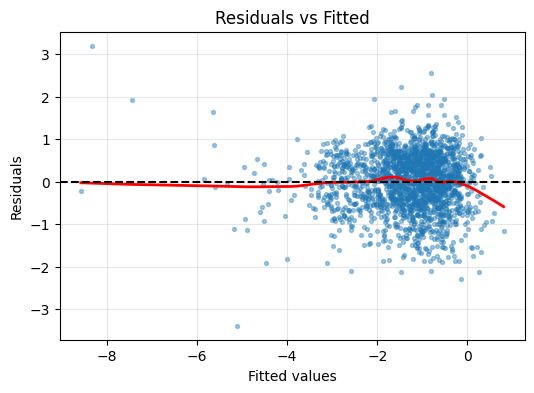

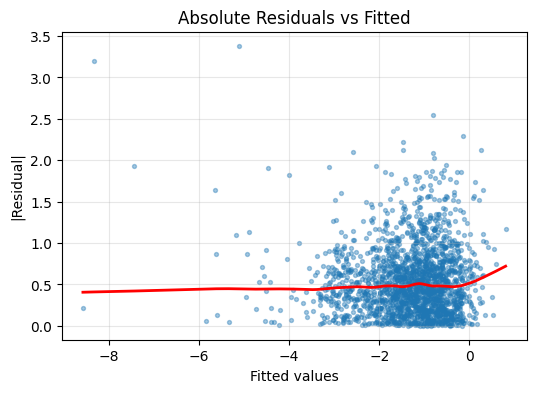

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['CALEFACCION_electrico']>0]
aux['target'] = np.log( aux['PER_CALEFACCION'] / (1-aux['PER_CALEFACCION']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### Cocina

Esta variable representa un problema ya que la mayoría de los hogares utiliza poca energía electrica para cocinar (menor del 5% del total del consumo).
Pese a esto el modelo utilizado presenta un buen ajuste aunque un R2 de 0.25.

_Es importante notar que el R2 y el modelo no tienen en cuenta a los hogares sin cocina electrica. Por lo que la precisión del modelo sería mucho más alta._


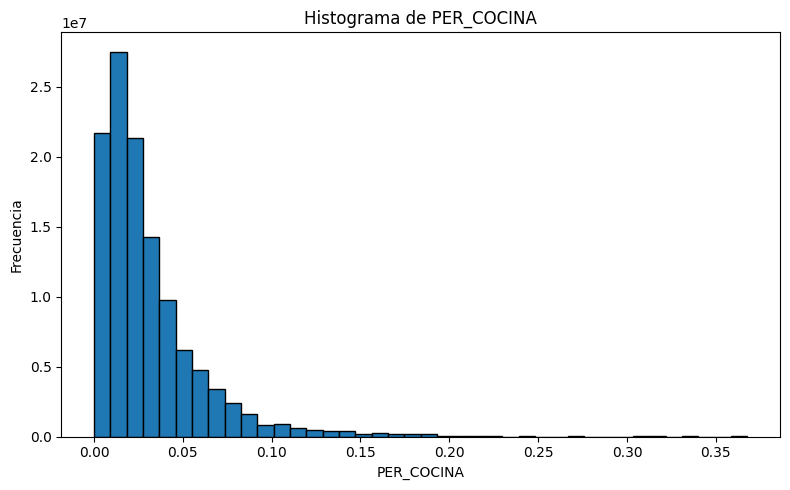

In [ ]:
weighted_histogram( data_consumo,
                   'PER_COCINA', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.257
Model:                            WLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     95.75
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        03:53:13   Log-Likelihood:                -6975.4
No. Observations:                5551   AIC:                         1.399e+04
Df Residuals:                    5530   BIC:                         1.413e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

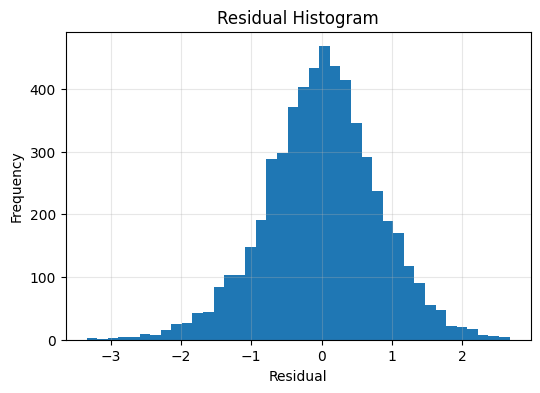

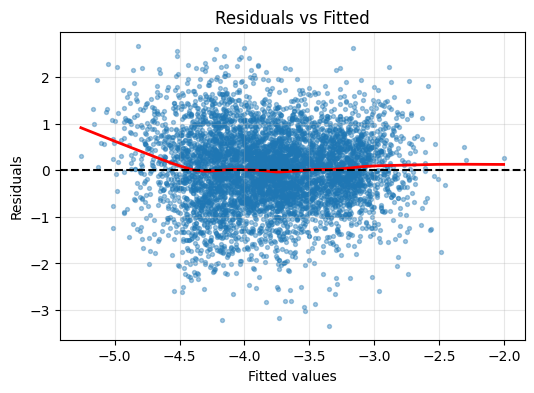

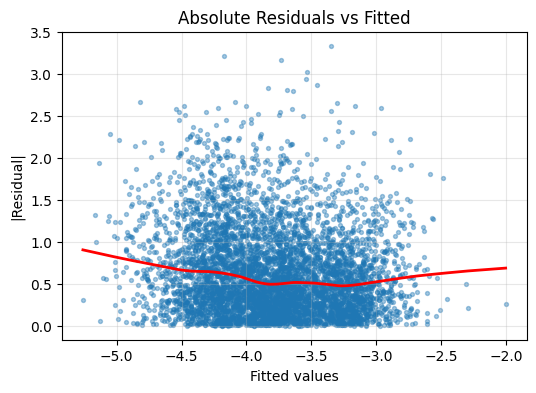

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['PER_COCINA']>0]
aux['target'] = np.log( aux['PER_COCINA'] / (1-aux['PER_COCINA']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### Iluminación

Presenta una distribución asimétrica hacia la derecha, sin ceros. Esto tiene sentido a que la iluminación eléctrica es uno de los servicios mínimos que un hogar utiliza.

El modelo presenta un buen ajuste con distribución normal de los residuos y varianza constante.

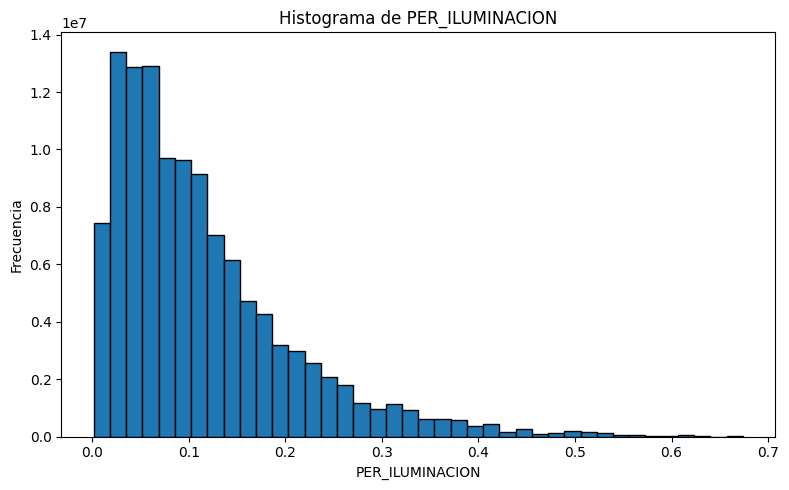

In [ ]:
weighted_histogram( data_consumo,
                   'PER_ILUMINACION', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.642
Model:                            WLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     494.8
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        03:56:49   Log-Likelihood:                -5057.8
No. Observations:                5544   AIC:                         1.016e+04
Df Residuals:                    5523   BIC:                         1.030e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

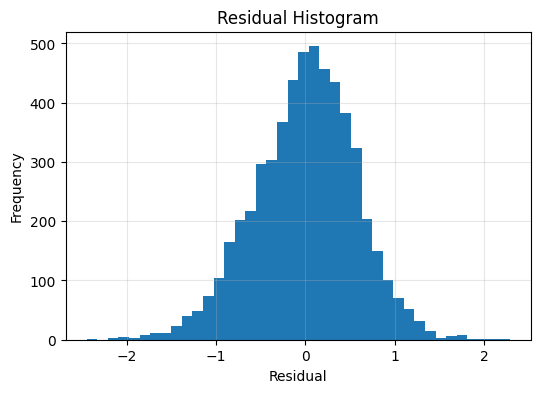

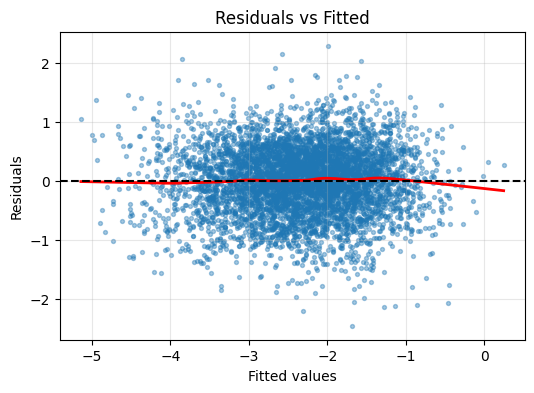

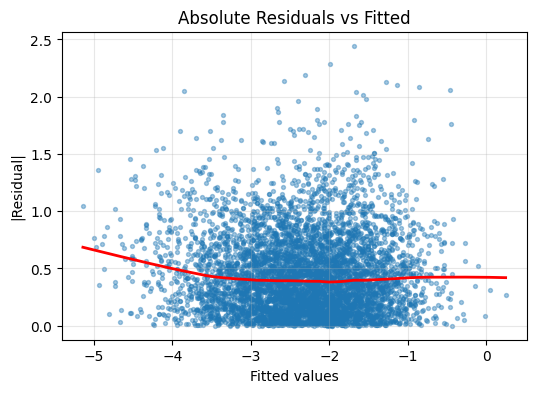

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[(data_consumo['LUCES_afuera_log']+data_consumo['LUCES_4_horas_log'])>0]
aux['target'] = np.log( aux['PER_ILUMINACION'] / (1-aux['PER_ILUMINACION']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

In [61]:
((10**data_consumo['VENTANAS_log']-1) / (10**data_consumo['DORMITORIOS_log']-1)).median()

4.166666666666667

### Lavado

El principal consumo del lavadao es el secarropas eléctrico. Por lo que hogares sin secarropas eléctrico presentan consumos cercanos a cero. Se los elimina.

El modelo ajusta relativamente bien con un R2 de 0.65, residuos normales y variancia constante. Parece haber un efecto cuadrático sin considerar pero el impacto es muy leve.

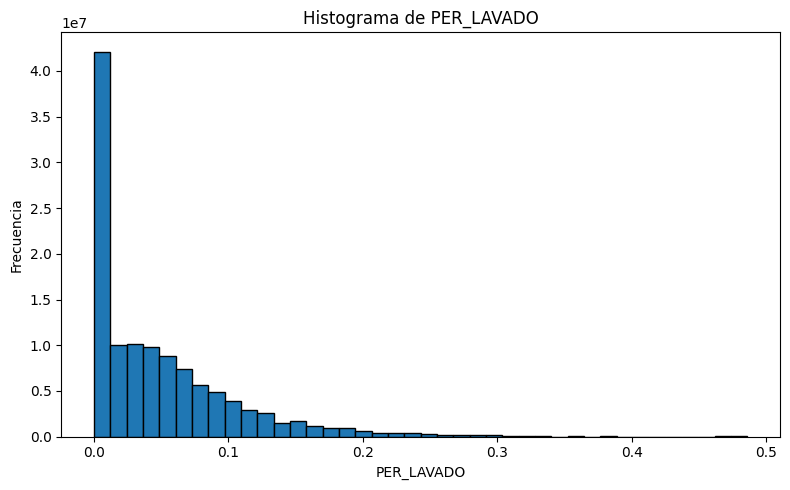

In [ ]:
weighted_histogram( data_consumo,
                   'PER_LAVADO', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.650
Model:                            WLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     344.4
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        03:57:51   Log-Likelihood:                -2926.4
No. Observations:                3738   AIC:                             5895.
Df Residuals:                    3717   BIC:                             6026.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

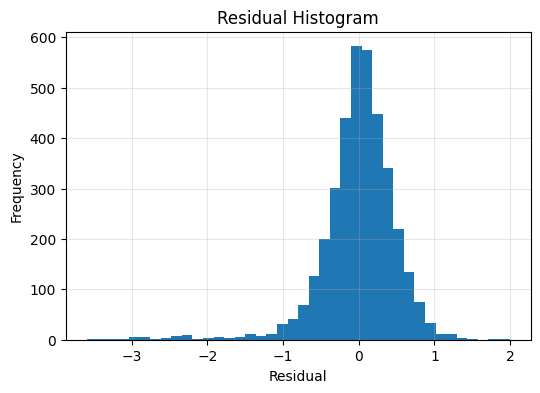

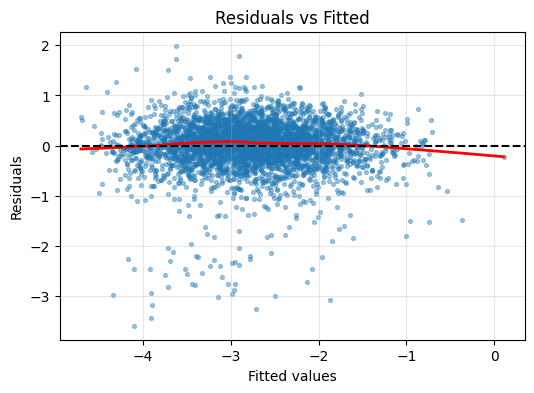

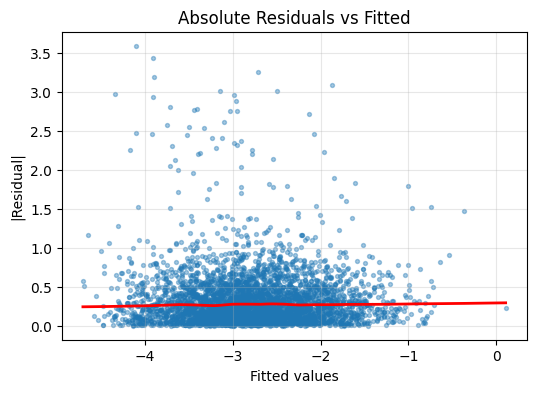

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log']>0]
aux['target'] = np.log( aux['PER_LAVADO'] / (1-aux['PER_LAVADO']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### Refrigeración

El gasto electrico en refrigeradores y freezer que ronda el 10% en todos los hogares.
Se descartan algunos pocos hogares sin estos servicios para crear el modelo.

El R2 es de 0.44, los residuos normales, el ajuste bueno y la variancia constante

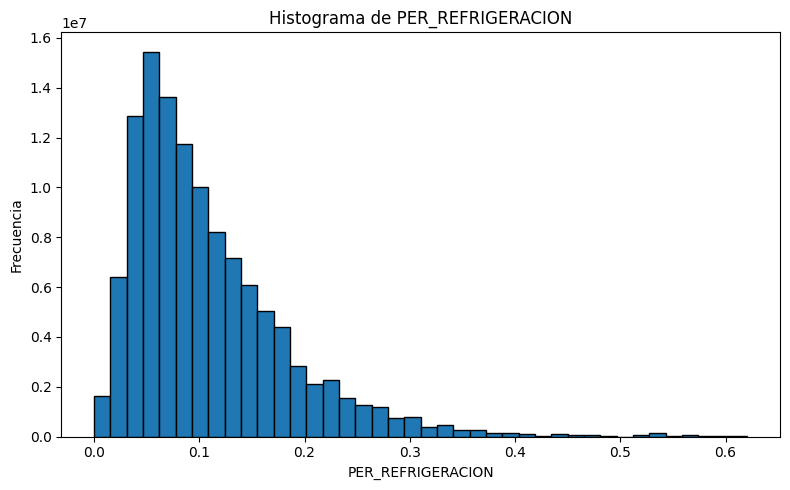

In [ ]:
weighted_histogram( data_consumo,
                   'PER_REFRIGERACION', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.441
Model:                            WLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     222.5
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:04:15   Log-Likelihood:                -5108.7
No. Observations:                5657   AIC:                         1.026e+04
Df Residuals:                    5636   BIC:                         1.040e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

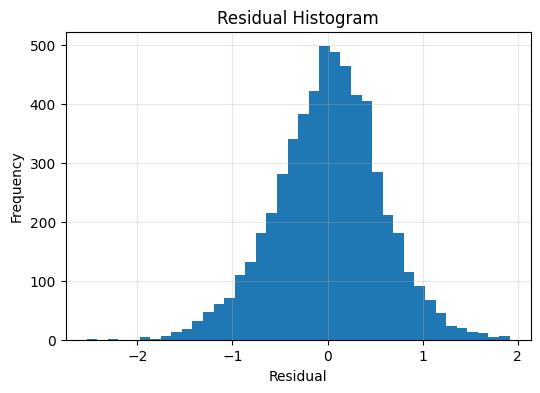

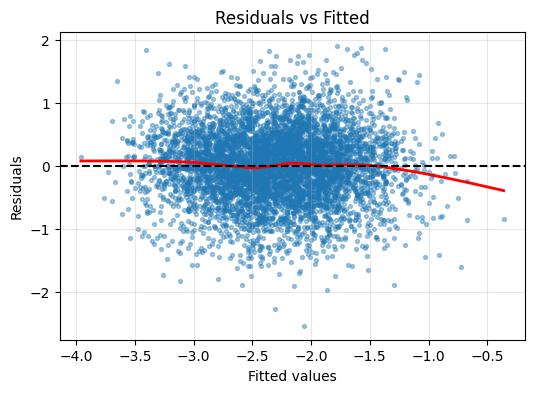

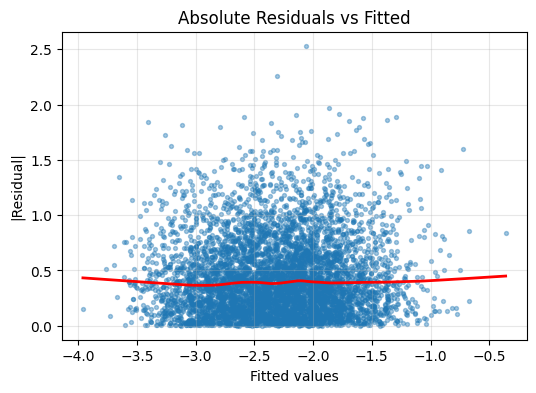

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[(data_consumo['REFRIGERADOR_log']+data_consumo['FREEZER_log'])>0 ]
aux['target'] = np.log( aux['PER_REFRIGERACION'] / (1-aux['PER_REFRIGERACION']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### TV

El consumo en televisores.

Para los hogares con televisor el R2 es del 0.44, residuos normales, ajuste bueno y variancia constante.


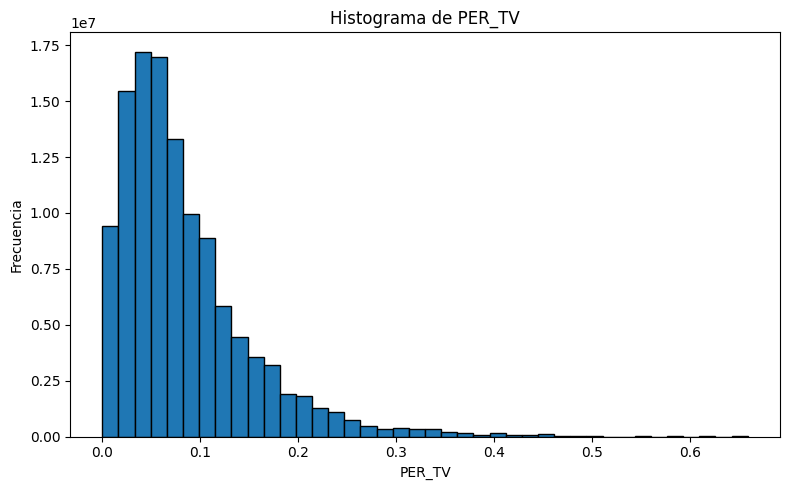

In [ ]:
weighted_histogram( data_consumo,
                   'PER_TV', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.498
Model:                            WLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     273.6
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:05:22   Log-Likelihood:                -5487.7
No. Observations:                5547   AIC:                         1.102e+04
Df Residuals:                    5526   BIC:                         1.116e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

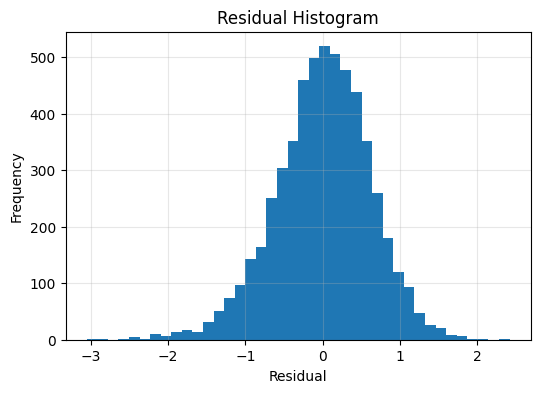

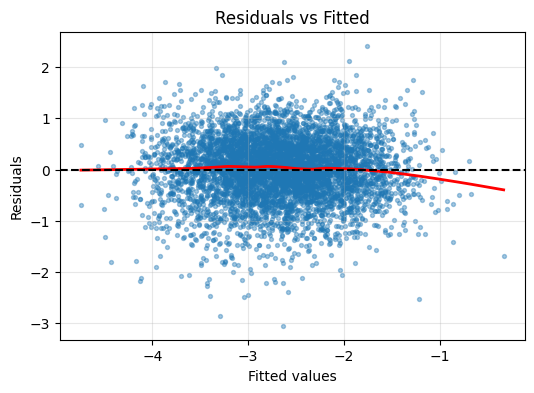

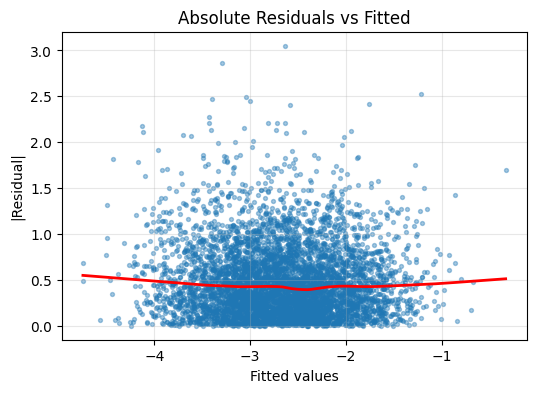

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['TV_log_X_TV_frecuencia_semana_log']>0]
aux['target'] = np.log( aux['PER_TV'] / (1-aux['PER_TV']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

### Otros

Los factores no conciderados como turbinas, ventiladores, piscinas, humificadores/deshumificadores. En ocaciones representan hasta el 80% del consumo de un hogar.

En este caso el R2 es de 0.42 aunque no se desartaron observaciones por lo que no se espera que este valor mejore. Los residuos presentan una cola derecha levemente más larga, y parece haber una falta de ajuste ocacionada por la división de la muestra en tres grupos.

Estos problemas son de esperarse debido a la gran cantidad de categorías de consumo mezcladas. Sin embargo el modelo aún resulta útil, en especial cuando se usa junto a los demás modelos.

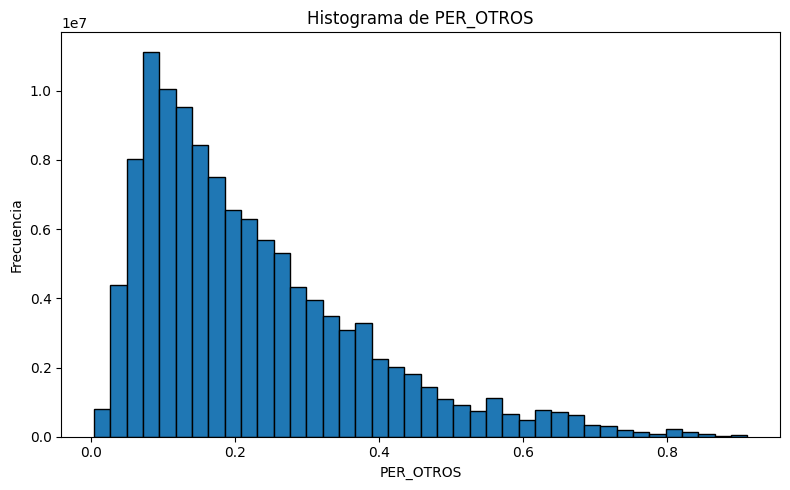

In [ ]:
weighted_histogram( data_consumo,
                   'PER_OTROS', 'NWEIGHT')

                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.426
Model:                            WLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     209.8
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:06:24   Log-Likelihood:                -6421.0
No. Observations:                5682   AIC:                         1.288e+04
Df Residuals:                    5661   BIC:                         1.302e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

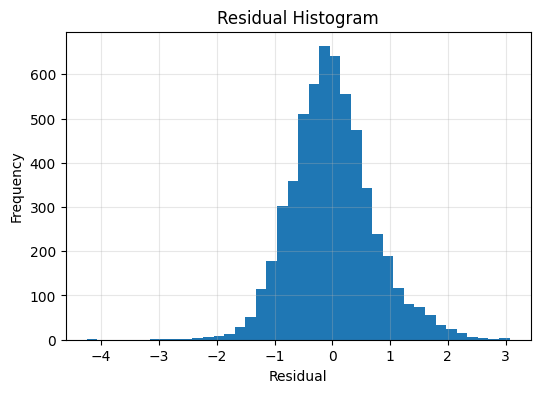

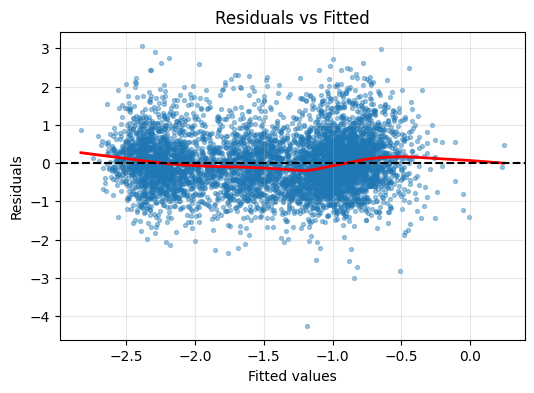

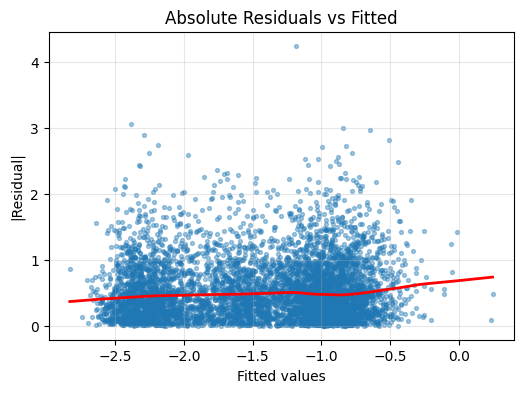

In [ ]:
aux = data_consumo.copy()
aux = aux.loc[aux['TV_log_X_TV_frecuencia_semana_log']>=0]
aux['target'] = np.log( aux['PER_OTROS'] / (1-aux['PER_OTROS']))
aux = aux[ predictores+[ 'target','NWEIGHT']]

residual_plot(
    data=aux,
    response = 'target',
    weight = 'NWEIGHT'
)

## ESTIMACION DEL ERROR DE LOS MODELOS

Se estiman (por validación cruzada) la mediana de cada categoría de consumo y la mediana del error absoluto del modelo. Además se disponen del error máximo para el 80, 90 y 95% de las observaciones.

| Categoría          | Mediana | R² Mediano | MAE Mediano | MAE 80% | MAE 90% | MAE 95% | SE Mediano |
| :----------------- | ------: | ---------: | ----------: | ------: | ------: | ------: | ---------: |
| AGUA_SANITARIA     |    0.23 |      0.542 |       0.043 |   0.089 |   0.128 |   0.155 |      0.076 |
| AIRE_ACONDICIONADO |    0.15 |      0.681 |       0.036 |   0.089 |   0.126 |   0.164 |      0.075 |
| CALEFACCION        |    0.23 |      0.456 |       0.070 |   0.143 |   0.195 |   0.227 |      0.114 |
| COCINA             |    0.02 |      0.148 |       0.010 |   0.023 |   0.036 |   0.053 |      0.025 |
| REFRIGERACION      |    0.09 |      0.363 |       0.029 |   0.058 |   0.087 |   0.114 |      0.055 |
| LAVADO             |    0.06 |      0.677 |       0.013 |   0.033 |   0.048 |   0.067 |      0.030 |
| ILUMINACION        |    0.09 |      0.559 |       0.026 |   0.064 |   0.095 |   0.124 |      0.059 |
| TV                 |    0.07 |      0.409 |       0.023 |   0.051 |   0.074 |   0.102 |      0.047 |
| OTROS              |    0.19 |      0.362 |       0.060 |   0.128 |   0.180 |   0.265 |      0.121 |


Recordemos que salvando el caso de OTROS e ILUMINACIÓN, esperamos una mejora en el R2 de los modelos al incorporar los valores que son cero.

Si observamos el MAE 90% (error absoluto mediano ) y lo comparamos con la mediana, por ejemplo AIRE ACONDCIONADO (mediana 0.15, MAE 90% = 0.126) presenta una mediana de 15%, que en uno de cada 10 casos puede errar por más de 12%, es decir que el consumo de un hogar podría ser del 27% cuando predecimos 15%.

Lejos de ser desalentador, entendemos estas diferencia como los diversos habitos de consumo, y al modelo como predictor del perfil promedio y no del consumo exacto.

In [ ]:


models = {"AGUA_SANITARIA": {'target' :'PER_AGUA_SANITARIA', 'filter': data_consumo['AGUA_CALIENTE_electrica']>0  },
          "AIRE_ACONDICIONADO": {'target' :'PER_AIRE_ACONDICIONADO', 'filter': data_consumo['AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log']>0  },
          "CALEFACCION": {'target' :'PER_CALEFACCION', 'filter': data_consumo['CALEFACCION_electrico']>0  },
          "COCINA": {'target' :'PER_COCINA', 'filter': data_consumo['PER_COCINA']>0  }, # solo 8 casos que tienen cocina electrica pero sin consumo, se descartan
          "REFRIGERACION": {'target' :'PER_REFRIGERACION', 'filter': (data_consumo['REFRIGERADOR_log']+data_consumo['FREEZER_log'])>0  },
          "LAVADO": {'target' :'PER_LAVADO', 'filter': data_consumo['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log']>0  },
          "ILUMINACION": {'target' :'PER_ILUMINACION', 'filter': (data_consumo['LUCES_afuera_log']+data_consumo['LUCES_4_horas_log'])>0  },
          "TV": {'target' :'PER_TV', 'filter': data_consumo['TV_log_X_TV_frecuencia_semana_log']>0  },
           "OTROS": {'target' :'PER_OTROS', 'filter': data_consumo['TV_log_X_TV_frecuencia_semana_log']>=0  },



}


for model_name in list(models.keys()):
  print(model_name, "      mediana:", np.median(data_consumo.loc[models[model_name]["filter"], models[model_name]["target"]]).round(2) )

  result = cross_validation_linear(
    data = data_consumo.loc[models[model_name]["filter"]],
    response = models[model_name]["target"] ,
    predictors = predictores ,
    weight = "NWEIGHT",
    kfolds=100,
    seed=123981,
    transformation = "logit"
)
  print(result.round(3))

AGUA_SANITARIA       mediana: 0.23
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.542       0.043    0.089    0.128    0.155      0.076
AIRE_ACONDICIONADO       mediana: 0.15
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.681       0.036    0.089    0.126    0.164      0.075
CALEFACCION       mediana: 0.23
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.456        0.07    0.143    0.195    0.227      0.114
COCINA       mediana: 0.02
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.148        0.01    0.023    0.036    0.053      0.025
REFRIGERACION       mediana: 0.09
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.363       0.029    0.058    0.087    0.114      0.055
LAVADO       mediana: 0.06
   Median_R2  Median_MAE  80%_MAE  90%_MAE  95%_MAE  Median_SE
0      0.677       0.013    0.033    0.048    0.067       0.03
ILUMINACION       mediana: 0.09
   Median_R2  Medi

# ETAPA 6: SERIALIZACIÓN


Se estiman los modelos uno a uno para luego guardar los coeficientes en un diccionario.

In [56]:
# MODELO BASE + CONSUMO
predictores = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'AGUA_CALIENTE_electrica'       ,
    'CALEFACCION_electrico'          ,
    'AIRE_ACONDICIONADO'             ,


             ]
results={}
df = data_consumo.copy()

  # Response
y = np.log10( 1+df['KWH'])

# Predictors
X = df[predictores]      # list of predictor names

X = sm.add_constant(X , has_constant="add")

# Fractional logit
model = sm.GLM(
  y,
  X,
  family=sm.families.Gaussian(),
  freq_weights=df["NWEIGHT"]   # optional
)

fit = model.fit()

results[name] = fit.params.to_dict()

print(results)


{'BASE': {'const': 2.592973740072916, 'CLIMA_grados_dias_enfriamiento_log': 0.09954211071782516, 'CLIMA_grados_dias_calefaccion_log': 0.0068828117583395205, 'DORMITORIOS_log': 0.49423717926161936, 'VENTANAS_log': 0.29802966480116805, 'HABITANTES_mayores_log': 0.37532452756698714, 'HABITANTES_menores_log': 0.11633833178520388, 'AGUA_CALIENTE_electrica': 0.13578276769858236, 'CALEFACCION_electrico': 0.14154324782537092, 'AIRE_ACONDICIONADO': 0.14961481104031835}}


In [57]:
predictores = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'AGUA_CALIENTE_electrica'       ,
    'CALEFACCION_electrico'          ,
    'AIRE_ACONDICIONADO'             ,


             ]
results={}

df = data_consumo.copy()

  # Response
df['logKWH'] = np.log10( 1+df['KWH'])

# Predictors
X = df[predictores]      # list of predictor names



# assume you already have a DataFrame called df
model_info = get_model(
    df=df,
    y_col="logKWH",
    x_cols= predictores,
    weight_col="NWEIGHT",
    print_dict=True          # set to False if you don't want the print
)

model_info = 
{'coefs': {'const': 2.5929737400729156,
           'CLIMA_grados_dias_enfriamiento_log': 0.09954211071782615,
           'CLIMA_grados_dias_calefaccion_log': 0.0068828117583398934,
           'DORMITORIOS_log': 0.49423717926161864,
           'VENTANAS_log': 0.2980296648011681,
           'HABITANTES_mayores_log': 0.3753245275669875,
           'HABITANTES_menores_log': 0.11633833178520547,
           'AGUA_CALIENTE_electrica': 0.13578276769858272,
           'CALEFACCION_electrico': 0.141543247825371,
           'AIRE_ACONDICIONADO': 0.1496148110403177},
 'cov': array([[ 4.19617993e-03, -7.34061576e-04, -5.24567026e-04,
        -5.58826254e-05, -3.49010194e-05, -2.57457388e-04,
         3.07743337e-05, -3.04906702e-05,  1.91838627e-05,
         1.26476650e-04],
       [-7.34061576e-04,  1.58173584e-04,  7.94203179e-05,
        -1.31862863e-07, -3.37229272e-06,  9.14971953e-06,
        -3.76133213e-06,  1.77008996e-06, -1.21121124e-05,
        -3.73554489e-05],
       [-5

In [52]:
predictores = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'             ,
    'CALEFACCION_electrico'          ,
    'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'                   ,
    'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'          ,
    'AGUA_CALIENTE_electrica',
    'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'               ,
    'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'                  ,
    'REFRIGERADOR_log'               ,
    'FREEZER_log'                  ,
    'TV_log',
    'TV_frecuencia_semana_log',
    'TV_log_X_TV_frecuencia_semana_log',
    'LUCES_afuera_log'               ,
    'LUCES_afuera_log_X_LUCES_4_horas_log'               ,
    'LUCES_4_horas_log' ,
    'HORNO_electrico' # añadida para represenar el uso de la electricidad para cocinar
    ]

results={}
name = "AVANZADO"
df = data_consumo.copy()

  # Response
df['logKWH'] = np.log10( 1+df['KWH'])

# Predictors
X = df[predictores]      # list of predictor names



# assume you already have a DataFrame called df
model_info = get_model(
    df=df,
    y_col="logKWH",
    x_cols= predictores,
    weight_col="NWEIGHT",
    print_dict=True          # set to False if you don't want the print
)

model_info = 
{'coefs': {'const': 2.9296587325313346,
           'CLIMA_grados_dias_enfriamiento_log': 0.08964217355401363,
           'CLIMA_grados_dias_calefaccion_log': -0.06839126630069724,
           'DORMITORIOS_log': 0.21775526340803178,
           'VENTANAS_log': 0.01909278274351897,
           'HABITANTES_mayores_log': 0.17979311406870724,
           'HABITANTES_menores_log': 0.08889625553697811,
           'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log': 0.0400269862602174,
           'CALEFACCION_electrico': -0.3434366540385792,
           'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log': 0.035577739405830006,
           'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log': 0.1417833832361335,
           'AGUA_CALIENTE_electrica': 0.04680842085588578,
           'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log': 0.038844882035696485,
           'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log': 0.11550370908701983,
           'REFRIGERADOR_log': 0.3149

In [ ]:
import statsmodels.api as sm
models = {"AGUA_SANITARIA": {'target' :'PER_AGUA_SANITARIA', 'filter': data_consumo['AGUA_CALIENTE_electrica']>0  },
          "AIRE_ACONDICIONADO": {'target' :'PER_AIRE_ACONDICIONADO', 'filter': data_consumo['AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log']>0  },
          "CALEFACCION": {'target' :'PER_CALEFACCION', 'filter': data_consumo['CALEFACCION_electrico']>0  },
          "COCINA": {'target' :'PER_COCINA', 'filter': data_consumo['PER_COCINA']>0  }, # solo 8 casos que tienen cocina electrica pero sin consumo, se descartan
          "REFRIGERACION": {'target' :'PER_REFRIGERACION', 'filter': (data_consumo['REFRIGERADOR_log']+data_consumo['FREEZER_log'])>0  },
          "LAVADO": {'target' :'PER_LAVADO', 'filter': data_consumo['SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log']>0  },
          "ILUMINACION": {'target' :'PER_ILUMINACION', 'filter': (data_consumo['LUCES_afuera_log']+data_consumo['LUCES_4_horas_log'])>0  },
          "TV": {'target' :'PER_TV', 'filter': data_consumo['TV_log_X_TV_frecuencia_semana_log']>0  },
           "OTROS": {'target' :'PER_OTROS', 'filter': data_consumo['TV_log_X_TV_frecuencia_semana_log']>=0  },



}

predictores = [
    'CLIMA_grados_dias_enfriamiento_log',
    'CLIMA_grados_dias_calefaccion_log',
    'DORMITORIOS_log'                ,
    'VENTANAS_log'                   ,
    'HABITANTES_mayores_log'         ,
    'HABITANTES_menores_log'         ,
    'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log'             ,
    'CALEFACCION_electrico'          ,
    'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log'                   ,
    'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log'          ,
    'AGUA_CALIENTE_electrica',
    'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log'               ,
    'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log'                  ,
    'REFRIGERADOR_log'               ,
    'FREEZER_log'                  ,
    'TV_log_X_TV_frecuencia_semana_log',
    'LUCES_afuera_log'               ,
    'LUCES_afuera_log_X_LUCES_4_horas_log'               ,
    'LUCES_4_horas_log' ,
    'HORNO_electrico' # añadida para represenar el uso de la electricidad para cocinar
    ]


results = {}

for name, info in models.items():

    # Filter data
    df = data_consumo.loc[info["filter"]].copy()

    # Response
    y = df[info["target"]]

    # Predictors
    X = df[predictores]      # list of predictor names

    X = sm.add_constant(X , has_constant="add")

    # Fractional logit
    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=df["NWEIGHT"]   # optional
    )

    fit = model.fit()

    results[name] = fit.params.to_dict()

print(results)

{'AGUA_SANITARIA': {'const': -0.09104648123676526, 'CLIMA_grados_dias_enfriamiento_log': -0.30483110533879176, 'CLIMA_grados_dias_calefaccion_log': 0.1850515313394157, 'DORMITORIOS_log': -0.40809906780141836, 'VENTANAS_log': -0.488954133266386, 'HABITANTES_mayores_log': 2.2576779488622365, 'HABITANTES_menores_log': 1.1914427372165903, 'AIRE_ACONDICIONADO_X_CLIMA_grados_dias_enfriamiento_log': -0.047167475166271504, 'CALEFACCION_electrico': 0.16001140501610586, 'VENTANAS_log_X_CLIMA_grados_dias_calefaccion_log': 0.04142613673092032, 'CALEFACCION_electrico_X_CLIMA_grados_dias_calefaccion_log': -0.1539499049314573, 'AGUA_CALIENTE_electrica': -0.09104648123676509, 'AGUA_CALIENTE_electrica_X_AGUA_CALIENTE_tamano_log': 0.044894758426246684, 'SECARROPAS_electrico_X_LAVARROPAS_frecuencia_log': -0.21152705582274275, 'REFRIGERADOR_log': -0.39838034263387223, 'FREEZER_log': -0.277956176287728, 'TV_log_X_TV_frecuencia_semana_log': -0.21645517846858184, 'LUCES_afuera_log': -0.417511573847914, 'LUCE

# ETAPA 7: OTROS SUBPRODUCTOS DEL MODELO



## PERCENTILES DEL CONSUMO

In [58]:
weighted_percentiles(data = data,
value = 'KWH'                     ,
                     weight = 'NWEIGHT',
                     percentiles = [0.20, 0.40, 0.60, 0.80])

{0.2: np.float64(4883.012),
 0.4: np.float64(7722.177),
 0.6: np.float64(10945.711),
 0.8: np.float64(15788.587)}

## PERCENTILES DEL CONSUMO

In [59]:
weighted_percentiles(data = data,
value = 'KWH'                     ,
                     weight = 'NWEIGHT',
                     percentiles = [0.05, 0.10, 0.15, 0.20,
                                    0.25, 0.30, 0.35, 0.40,
                                    0.45, 0.50, 0.55, 0.60,
                                    0.65, 0.70, 0.75, 0.80,
                                    0.85, 0.90, 0.95])

{0.05: np.float64(2483.479),
 0.1: np.float64(3389.987),
 0.15: np.float64(4150.0),
 0.2: np.float64(4883.012),
 0.25: np.float64(5609.369),
 0.3: np.float64(6323.614),
 0.35: np.float64(6997.806),
 0.4: np.float64(7722.177),
 0.45: np.float64(8464.097),
 0.5: np.float64(9300.434),
 0.55: np.float64(10020.797),
 0.6: np.float64(10945.711),
 0.65: np.float64(11947.0),
 0.7: np.float64(12986.41),
 0.75: np.float64(14316.106),
 0.8: np.float64(15788.587),
 0.85: np.float64(17518.615),
 0.9: np.float64(19974.706),
 0.95: np.float64(23642.508)}